In [35]:
import os
import re
import itertools
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb

from catboost import CatBoostClassifier
from statsmodels.nonparametric.smoothers_lowess import lowess

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
from matplotlib import colors

warnings.filterwarnings("ignore")

RANDOM_STATE = 123
TARGET = "Metastasis"

OUT_DIR = "outs_model_compare"
NETWORK_DIR = f"{OUT_DIR}/shap_interaction_network"
PDP_DIR = f"{OUT_DIR}/pdp_2d"

for d in [OUT_DIR, NETWORK_DIR, PDP_DIR]:
    os.makedirs(d, exist_ok=True)

np.random.seed(RANDOM_STATE)

In [36]:
SHCC_data = pd.read_csv("SHCC_data_cleaned.csv")
print("原始数据维度:", SHCC_data.shape)

exclude_cols = [
    "ID", "pathID", "Year",
    "TTPstatus", "TTPM",
    "OSstatus", "OSM",
    "DFSstatus", "DFSM",
    "recurrence",
    "pNstage", "pMstage", "pTNMstage", "TNMstage",
    "Ttype", "Tsize",
    "LymphNodePositive", "LymphNodeTotal",
    "TD", "livermeta", "lungmeta", "bonemeta", "brainmeta",
    "MMRtest", "MMRMSIstatus", "MMRMSItest", "MMRstatus",
    "Location_minor",
    "PCNA", "nm23", "COX2", "EGFR",
    "P21-1", "P53-1", "CD44-1",
    "CRM", "NAC", "MLH1", "MSH2", "MSH6", "PMS2", "EMR"
]

exclude_cols = list(dict.fromkeys(exclude_cols))

feature_cols = [
    c for c in SHCC_data.columns
    if c not in exclude_cols + [TARGET]
]

df = SHCC_data[feature_cols + [TARGET]].copy()
print("初始建模数据维度:", df.shape)

原始数据维度: (19070, 61)
初始建模数据维度: (19070, 20)


In [37]:
df = df.replace("x", "Unknown")

gene_l1_cols = ["KRAS_result_L1", "NRAS_result_L1", "BRAF_result_L1", "MSI_result_L1"]
exist_gene_l1_cols = [c for c in gene_l1_cols if c in df.columns]

df[exist_gene_l1_cols] = df[exist_gene_l1_cols].replace(
    ["2", "3", 2, 3],
    "Unknown"
)

drop_molecular_cols = [
    "MSI_result_L1", "MSI_result_L2",
    "KRAS_result_L2", "BRAF_result_L2", "NRAS_result_L2"
]
df = df.drop(columns=[c for c in drop_molecular_cols if c in df.columns])

gene_filter_cols = [
    c for c in ["KRAS_result_L1", "NRAS_result_L1", "BRAF_result_L1"]
    if c in df.columns
]

if gene_filter_cols:
    df = df[~df[gene_filter_cols].isin(["Unknown"]).any(axis=1)].copy()

for c in ["Pathology_class", "Location"]:
    if c in df.columns:
        df[c] = df[c].astype("category")

required_numeric_cols = [
    "Gender",
    "Lymphovasscular invasion",
    "Perineural invasion"
]

for c in required_numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

exist_required_cols = [c for c in required_numeric_cols if c in df.columns]
df = df.dropna(subset=exist_required_cols)

if "max_diameter" in df.columns:
    df["max_diameter"] = pd.to_numeric(df["max_diameter"], errors="coerce")
    df = df[df["max_diameter"] <= 12].copy()

df = df.dropna(subset=[TARGET]).copy()

target_values = sorted(pd.Series(df[TARGET].dropna().astype(str).unique()).tolist())

if set(target_values).issubset({"0", "1"}):
    df[TARGET] = df[TARGET].astype(str).astype(int)
else:
    df[TARGET] = df[TARGET].astype("category")
    if df[TARGET].nunique() != 2:
        raise ValueError(f"{TARGET} 必须是二分类变量")
    df[TARGET] = df[TARGET].cat.codes


In [38]:
keep_feature_cols = [c for c in df.columns if c != TARGET]

cat_cols = (
    df[keep_feature_cols]
    .select_dtypes(include=["object", "category", "string"])
    .columns
    .tolist()
)

X_all = pd.get_dummies(
    df[keep_feature_cols],
    columns=cat_cols,
    drop_first=False,
    dtype=int
)

y_all = df[TARGET].astype(int).values

imputer = SimpleImputer(strategy="median")
X_all_imp = pd.DataFrame(
    imputer.fit_transform(X_all),
    columns=X_all.columns,
    index=X_all.index
)

X_all_imp.to_csv(f"{OUT_DIR}/X_all_onehot.csv", index=False, encoding="utf-8-sig")

X_train, X_test, y_train, y_test = train_test_split(
    X_all_imp,
    y_all,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_all
)

In [39]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos if pos > 0 else 1.0

models = {
    "DecisionTree": DecisionTreeClassifier(
        max_depth=4,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": xgb.XGBClassifier(
        booster="gbtree",
        objective="binary:logistic",
        eval_metric="auc",
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        n_estimators=300,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        tree_method="hist"
    ),

    "CatBoost": CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=300,
        depth=4,
        learning_rate=0.05,
        auto_class_weights="Balanced",
        random_seed=RANDOM_STATE,
        verbose=0
    )
}

In [40]:
results = []
roc_data = {}
fitted_models = {}

for name, model in models.items():
    print(f"\n===== {name} =====")

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    auc = roc_auc_score(y_test, y_prob)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    results.append({
        "Model": name,
        "AUC": auc,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    })

    roc_data[name] = (fpr, tpr, auc)
    fitted_models[name] = model

    print(f"AUC      : {auc:.4f}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1       : {f1:.4f}")

results_df = (
    pd.DataFrame(results)
    .sort_values("AUC", ascending=False)
    .reset_index(drop=True)
)

print(results_df)

results_df.to_csv(
    f"{OUT_DIR}/model_comparison_results.csv",
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(6, 6), dpi=300)

for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Tree-Based Models")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/model_comparison_roc.pdf", dpi=300, bbox_inches="tight")
plt.close()

best_model_name = results_df.loc[0, "Model"]
best_model = fitted_models[best_model_name]
safe_name = best_model_name.lower().replace(" ", "_")

print(f"\n最佳模型: {best_model_name}")


===== DecisionTree =====
AUC      : 0.7858
Accuracy : 0.7034
Precision: 0.8699
Recall   : 0.6304
F1       : 0.7310

===== RandomForest =====
AUC      : 0.8040
Accuracy : 0.7183
Precision: 0.8933
Recall   : 0.6353
F1       : 0.7425

===== ExtraTrees =====
AUC      : 0.7991
Accuracy : 0.7034
Precision: 0.8829
Recall   : 0.6181
F1       : 0.7271

===== XGBoost =====
AUC      : 0.8133
Accuracy : 0.7441
Precision: 0.8816
Recall   : 0.6928
F1       : 0.7759

===== CatBoost =====
AUC      : 0.8131
Accuracy : 0.7355
Precision: 0.8857
Recall   : 0.6732
F1       : 0.7650
          Model       AUC  Accuracy  Precision    Recall        F1
0       XGBoost  0.813291  0.744131   0.881620  0.692778  0.775874
1      CatBoost  0.813100  0.735524   0.885668  0.673195  0.764951
2  RandomForest  0.803970  0.718310   0.893287  0.635251  0.742489
3    ExtraTrees  0.799081  0.703443   0.882867  0.618115  0.727142
4  DecisionTree  0.785800  0.703443   0.869932  0.630355  0.731015

最佳模型: XGBoost


In [41]:
pred_prob = best_model.predict_proba(X_test)[:, 1]
pred_class = (pred_prob >= 0.5).astype(int)

auc_value = roc_auc_score(y_test, pred_prob)
acc_value = accuracy_score(y_test, pred_class)
precision_value = precision_score(y_test, pred_class, zero_division=0)
recall_value = recall_score(y_test, pred_class, zero_division=0)
f1_value = f1_score(y_test, pred_class, zero_division=0)

print(f"\n===== {best_model_name} 结果 =====")
print(f"AUC       : {auc_value:.4f}")
print(f"Accuracy  : {acc_value:.4f}")
print(f"Precision : {precision_value:.4f}")
print(f"Recall    : {recall_value:.4f}")
print(f"F1-score  : {f1_value:.4f}")

report_text = classification_report(y_test, pred_class, digits=4)
print("\nClassification Report:")
print(report_text)

with open(f"{OUT_DIR}/classification_report_{safe_name}.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

pred_df = pd.DataFrame({
    "y_test": y_test,
    "pred_prob": pred_prob,
    "pred_class": pred_class
})

pred_df.to_csv(
    f"{OUT_DIR}/test_predictions_{safe_name}.csv",
    index=False,
    encoding="utf-8-sig"
)

metric_df = pd.DataFrame({
    "Model": [best_model_name],
    "AUC": [auc_value],
    "Accuracy": [acc_value],
    "Precision": [precision_value],
    "Recall": [recall_value],
    "F1_score": [f1_value]
})

metric_df.to_csv(
    f"{OUT_DIR}/{safe_name}_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)


===== XGBoost 结果 =====
AUC       : 0.8133
Accuracy  : 0.7441
Precision : 0.8816
Recall    : 0.6928
F1-score  : 0.7759

Classification Report:
              precision    recall  f1-score   support

           0     0.6053    0.8351    0.7019       461
           1     0.8816    0.6928    0.7759       817

    accuracy                         0.7441      1278
   macro avg     0.7435    0.7640    0.7389      1278
weighted avg     0.7820    0.7441    0.7492      1278




Confusion Matrix:
        Pred_0  Pred_1
True_0     385      76
True_1     251     566


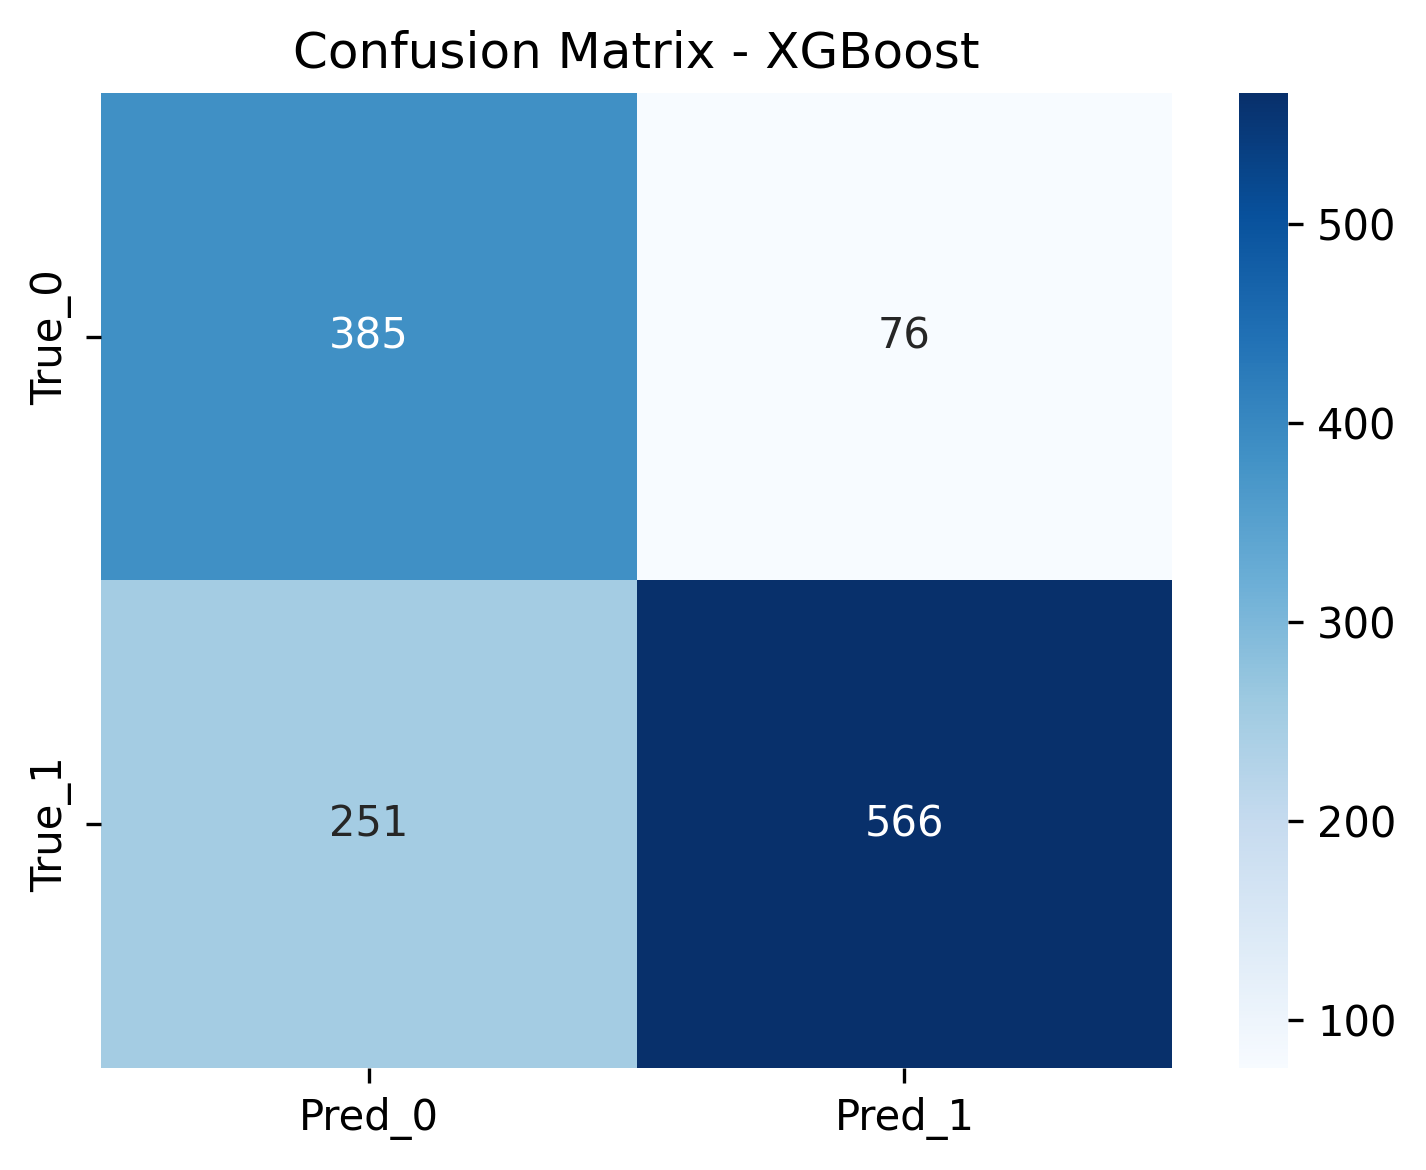

In [42]:
fpr, tpr, _ = roc_curve(y_test, pred_prob)

plt.figure(figsize=(6, 6), dpi=300)
plt.plot(fpr, tpr, lw=2, label=f"{best_model_name} (AUC = {auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{best_model_name} ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ROC_curve_{safe_name}.pdf", dpi=300, bbox_inches="tight")
plt.close()

cm = confusion_matrix(y_test, pred_class)
cm_df = pd.DataFrame(
    cm,
    index=["True_0", "True_1"],
    columns=["Pred_0", "Pred_1"]
)

print("\nConfusion Matrix:")
print(cm_df)

cm_df.to_csv(
    f"{OUT_DIR}/confusion_matrix_{safe_name}.csv",
    encoding="utf-8-sig"
)

plt.figure(figsize=(5, 4), dpi=300)
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrix_{safe_name}.pdf", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


Top 30 XGBoost feature importance:
                     Feature  Importance
0   Lymphovasscular invasion    0.543471
1        Perineural invasion    0.065008
2   Mucinous subtype_Unknown    0.044236
3                    pTstage    0.040908
4          Pathology_class_0    0.036880
5               max_diameter    0.018284
6         Mucinous subtype_0    0.017919
7            Differentiation    0.017529
8                        Age    0.016662
9           NRAS_result_L1_0    0.016515
10         Pathology_class_1    0.016402
11          NRAS_result_L1_1    0.015373
12                      ki67    0.015240
13                    Gender    0.015164
14          BRAF_result_L1_1    0.014455
15                Location_2    0.014315
16          KRAS_result_L1_0    0.014130
17                Location_1    0.014068
18                Location_3    0.013631
19         Pathology_class_2    0.013380
20          KRAS_result_L1_1    0.012478
21          BRAF_result_L1_0    0.012040
22        Mucinous su

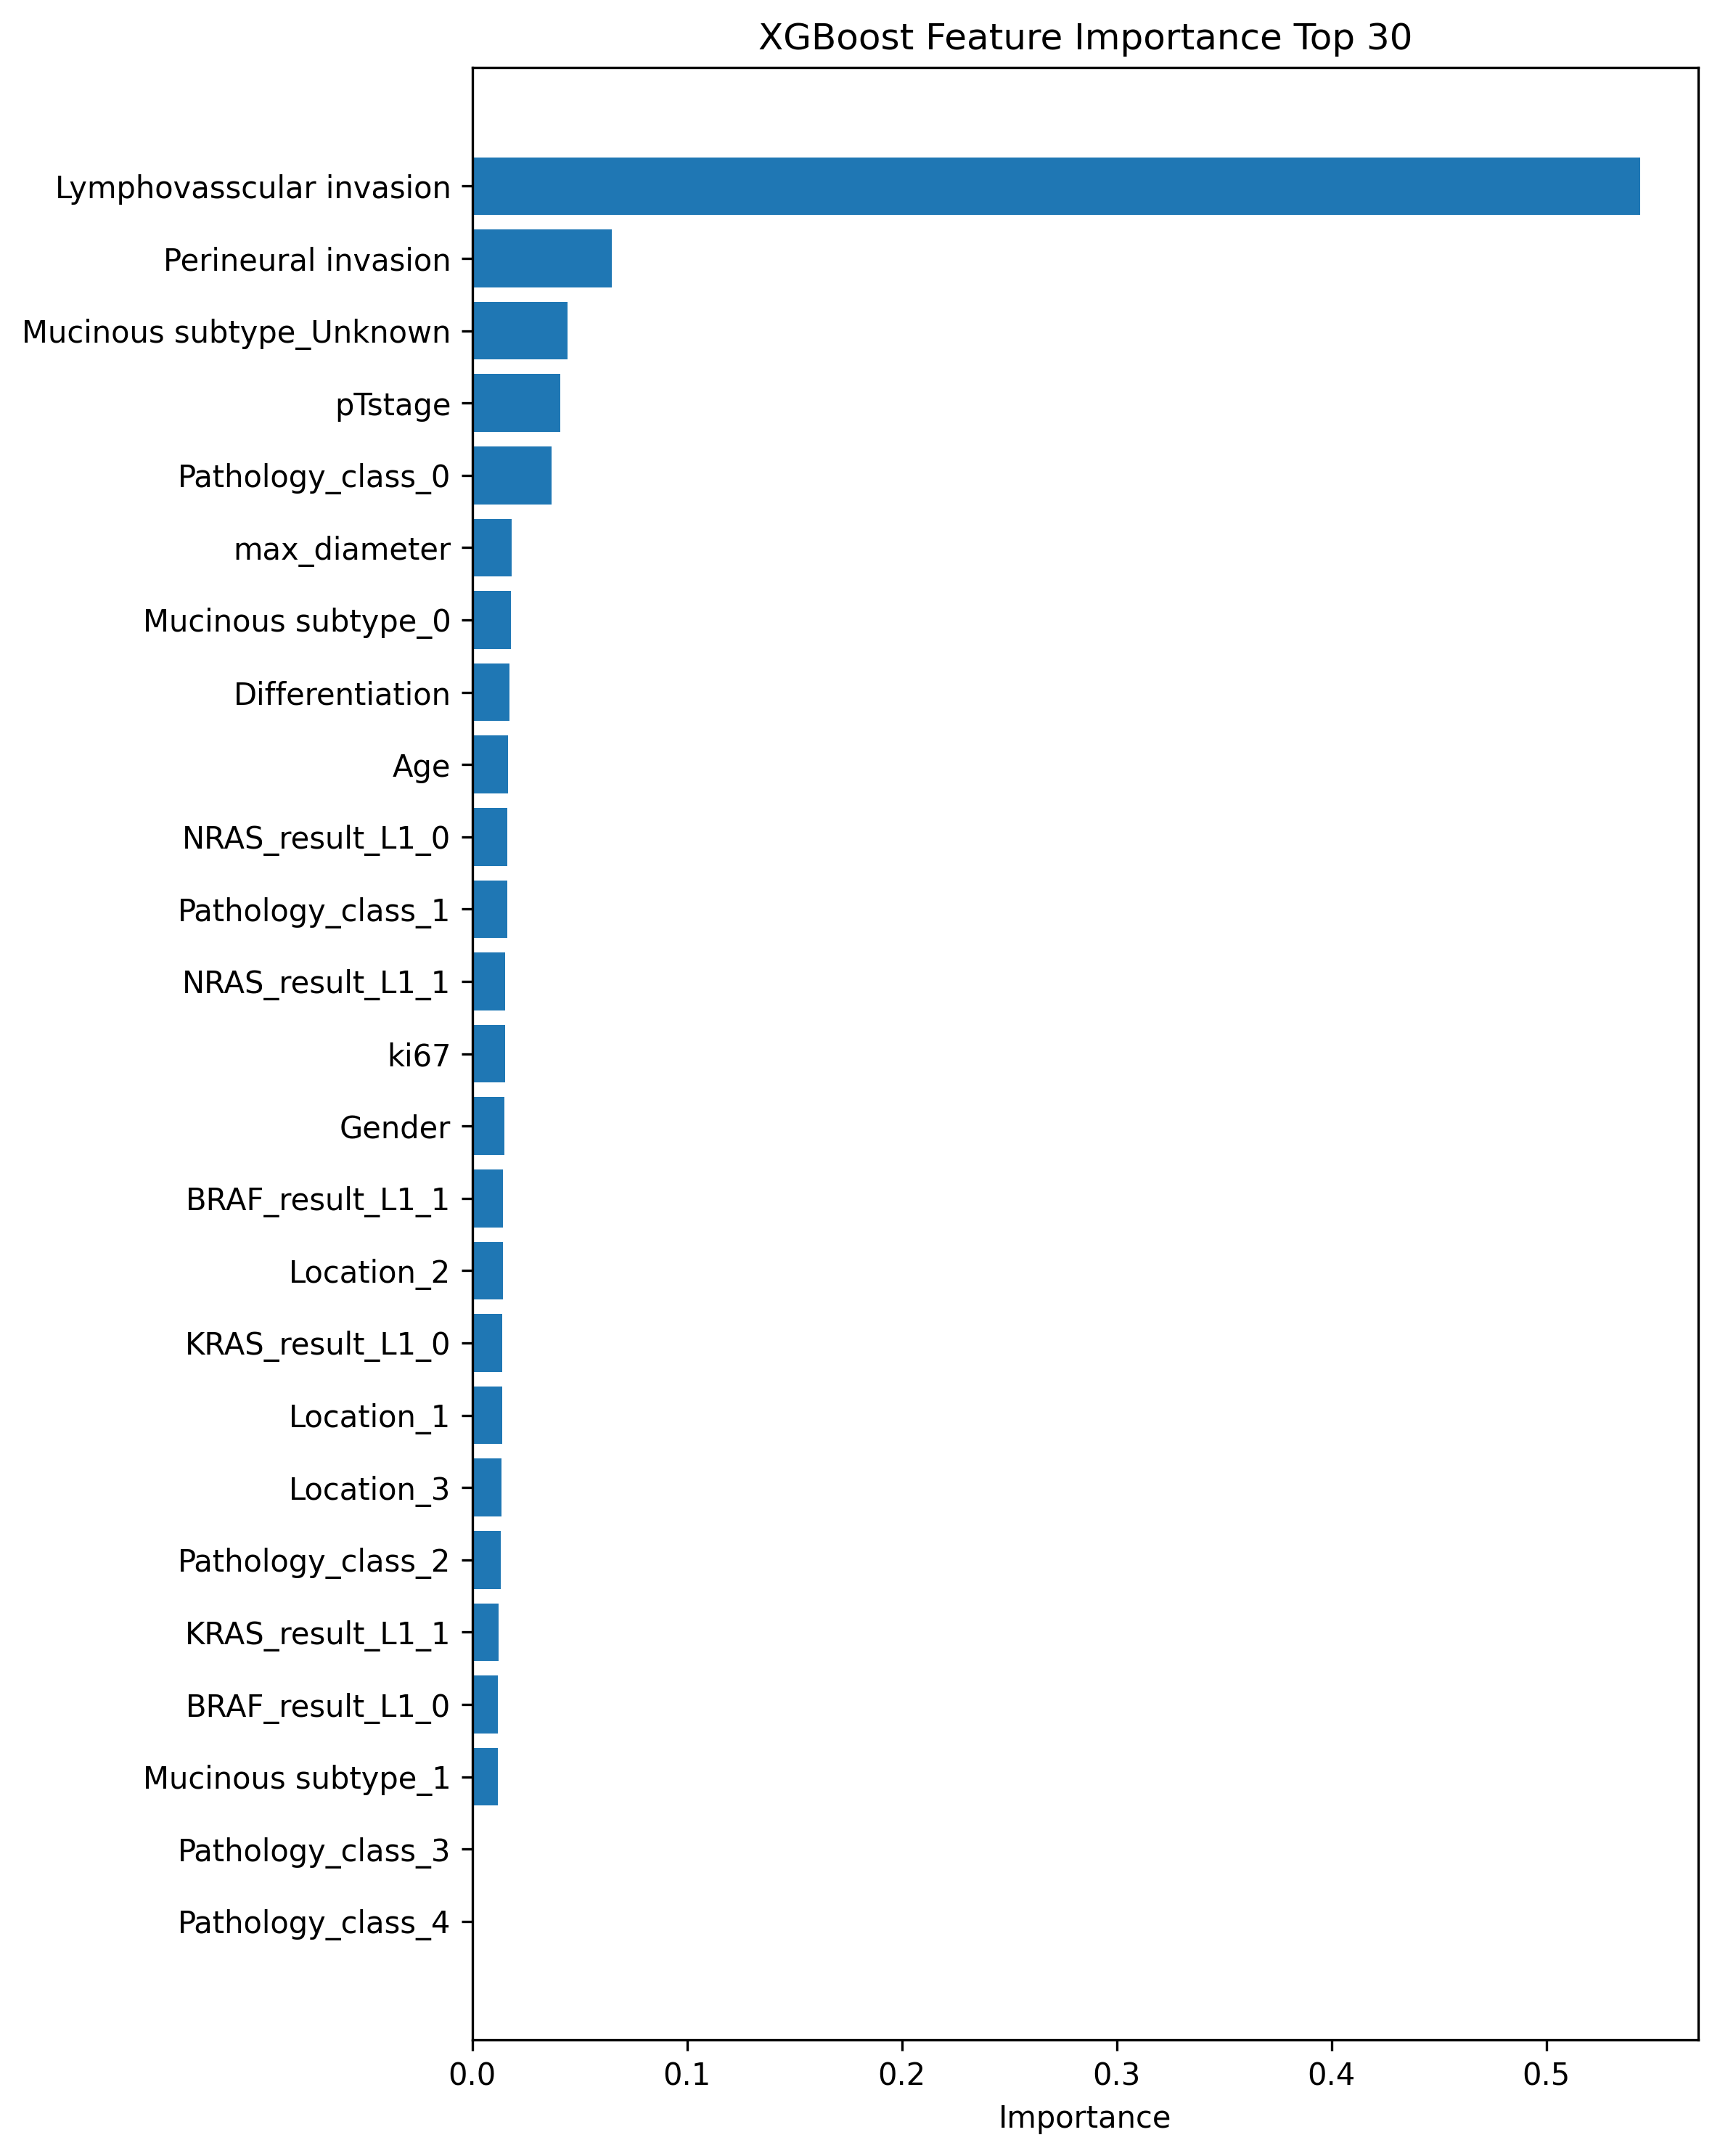

In [43]:
feature_names = X_train.columns.tolist()

if best_model_name == "CatBoost":
    importances = best_model.get_feature_importance()
elif hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
else:
    importances = None

if importances is not None:
    imp = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances
        })
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\nTop 30 {best_model_name} feature importance:")
    print(imp.head(30))

    imp.to_csv(
        f"{OUT_DIR}/{safe_name}_importance_all.csv",
        index=False,
        encoding="utf-8-sig"
    )

    top30_imp = imp.head(30).sort_values("Importance", ascending=True)

    plt.figure(figsize=(8, 10), dpi=300)
    plt.barh(top30_imp["Feature"], top30_imp["Importance"])
    plt.xlabel("Importance")
    plt.title(f"{best_model_name} Feature Importance Top 30")
    plt.tight_layout()
    plt.savefig(
        f"{OUT_DIR}/{safe_name}_importance_top30.pdf",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()
else:
    print(f"{best_model_name} 不支持直接导出 feature_importances_")

In [44]:
def get_binary_shap_values(explainer, X):
    shap_result = explainer.shap_values(X)

    if isinstance(shap_result, list):
        shap_result = shap_result[1] if len(shap_result) > 1 else shap_result[0]

    shap_array = np.asarray(shap_result)

    if shap_array.ndim == 3:
        if shap_array.shape[-1] == 2:
            shap_array = shap_array[:, :, 1]
        elif shap_array.shape[0] == 2:
            shap_array = shap_array[1]

    return shap_array


def get_binary_base_value(explainer):
    expected_value = explainer.expected_value
    arr = np.asarray(expected_value).reshape(-1)

    if arr.size > 1:
        return float(arr[1])

    return float(arr[0])


explainer = shap.TreeExplainer(best_model)
shap_values = get_binary_shap_values(explainer, X_train)
base_val = get_binary_base_value(explainer)

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_imp = (
    pd.DataFrame({
        "Feature": feature_names,
        "mean_abs_shap": mean_abs_shap
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print(f"\nTop 30 {best_model_name} mean(|SHAP|):")
print(shap_imp.head(30))

shap_imp.to_csv(
    f"{OUT_DIR}/{safe_name}_shap_mean_abs_importance.csv",
    index=False,
    encoding="utf-8-sig"
)


Top 30 XGBoost mean(|SHAP|):
                     Feature  mean_abs_shap
0   Lymphovasscular invasion       1.053784
1                    pTstage       0.322374
2        Perineural invasion       0.279697
3          Pathology_class_0       0.219683
4                        Age       0.186329
5               max_diameter       0.155825
6            Differentiation       0.078820
7                       ki67       0.071920
8                     Gender       0.068221
9           KRAS_result_L1_0       0.044757
10  Mucinous subtype_Unknown       0.044726
11                Location_1       0.040864
12                Location_3       0.038520
13        Mucinous subtype_0       0.035878
14         Pathology_class_1       0.017655
15          NRAS_result_L1_0       0.017513
16                Location_2       0.017245
17          KRAS_result_L1_1       0.009466
18        Mucinous subtype_1       0.006779
19          BRAF_result_L1_0       0.005439
20         Pathology_class_2       0.004220
21

<Figure size 640x480 with 0 Axes>

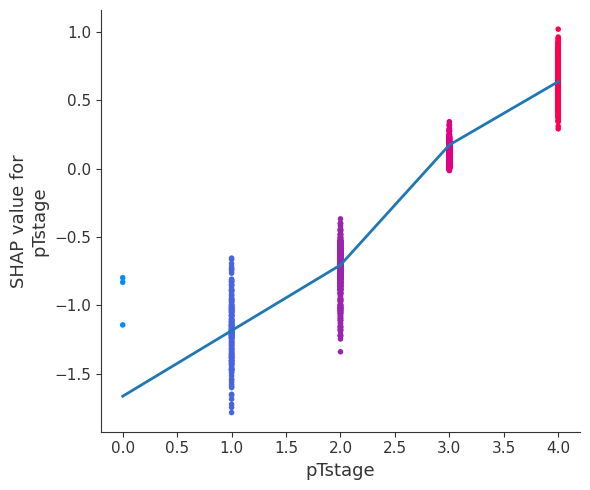

<Figure size 640x480 with 0 Axes>

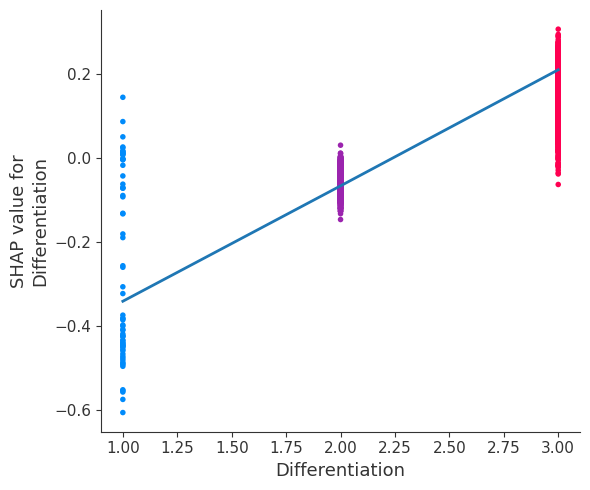

<Figure size 640x480 with 0 Axes>

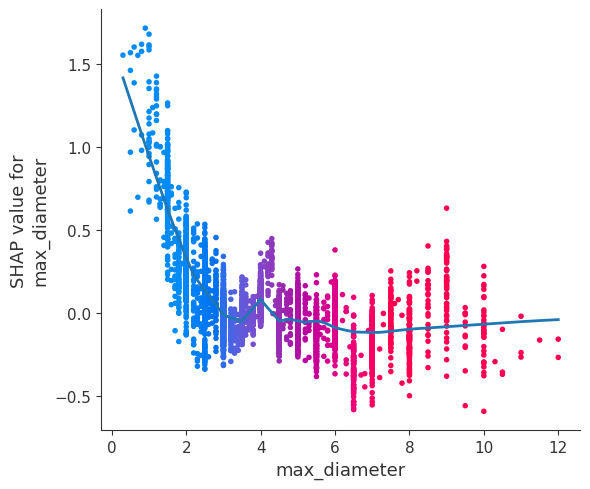

<Figure size 640x480 with 0 Axes>

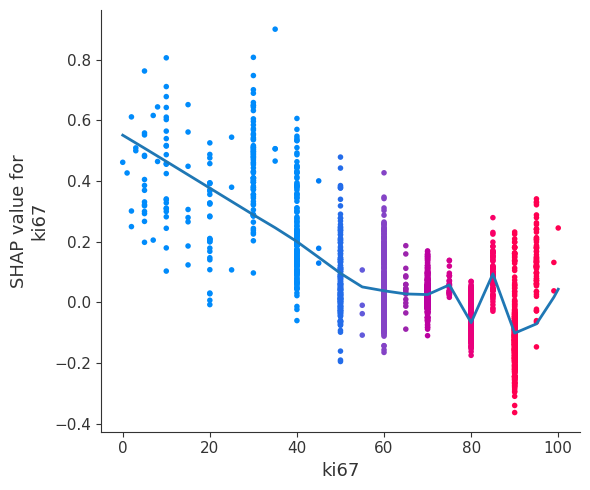

<Figure size 640x480 with 0 Axes>

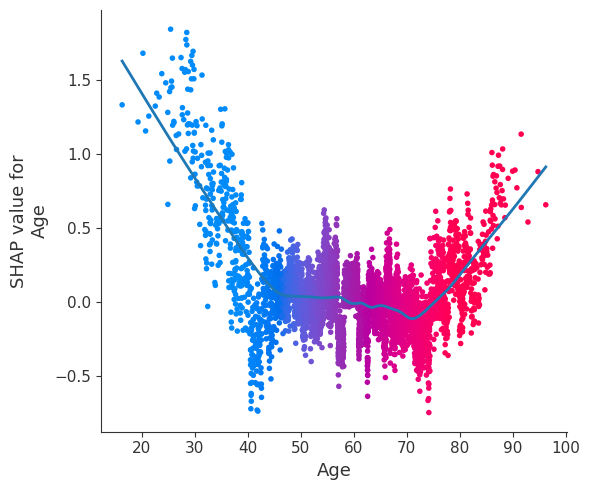

<Figure size 640x480 with 0 Axes>

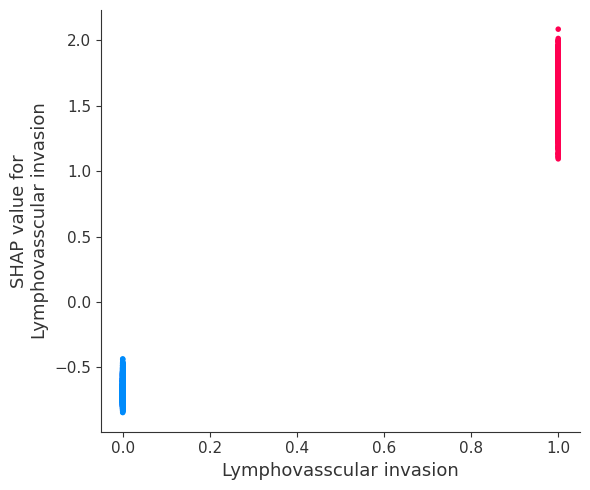

In [45]:
def safe_text(x):
    return re.sub(r"[^0-9A-Za-z_\-]+", "_", str(x))


plt.figure()
shap.summary_plot(shap_values, X_train, show=False)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/{safe_name}_shap_summary.pdf", dpi=300, bbox_inches="tight")
plt.close()

plt.figure()
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/{safe_name}_shap_summary_bar.pdf", dpi=300, bbox_inches="tight")
plt.close()

candidate_features = [
    "pTstage",
    "Differentiation",
    "max_diameter",
    "NAC",
    "ki67",
    "Age",
    "Lymphovasscular invasion"
]

for feat in candidate_features:
    if feat not in X_train.columns:
        continue

    plt.figure()
    shap.dependence_plot(
        feat,
        shap_values,
        X_train,
        interaction_index=feat,
        show=False
    )

    feat_idx = X_train.columns.get_loc(feat)
    x = X_train[feat].values
    y = shap_values[:, feat_idx]

    mask = pd.notna(x) & pd.notna(y)
    x_clean = x[mask]
    y_clean = y[mask]

    if len(np.unique(x_clean)) > 2:
        fit = lowess(y_clean, x_clean, frac=0.3, it=2, return_sorted=True)
        plt.plot(fit[:, 0], fit[:, 1], linewidth=2)

    plt.tight_layout()
    plt.savefig(
        f"{OUT_DIR}/{safe_name}_shap_dependence_{safe_text(feat)}.pdf",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

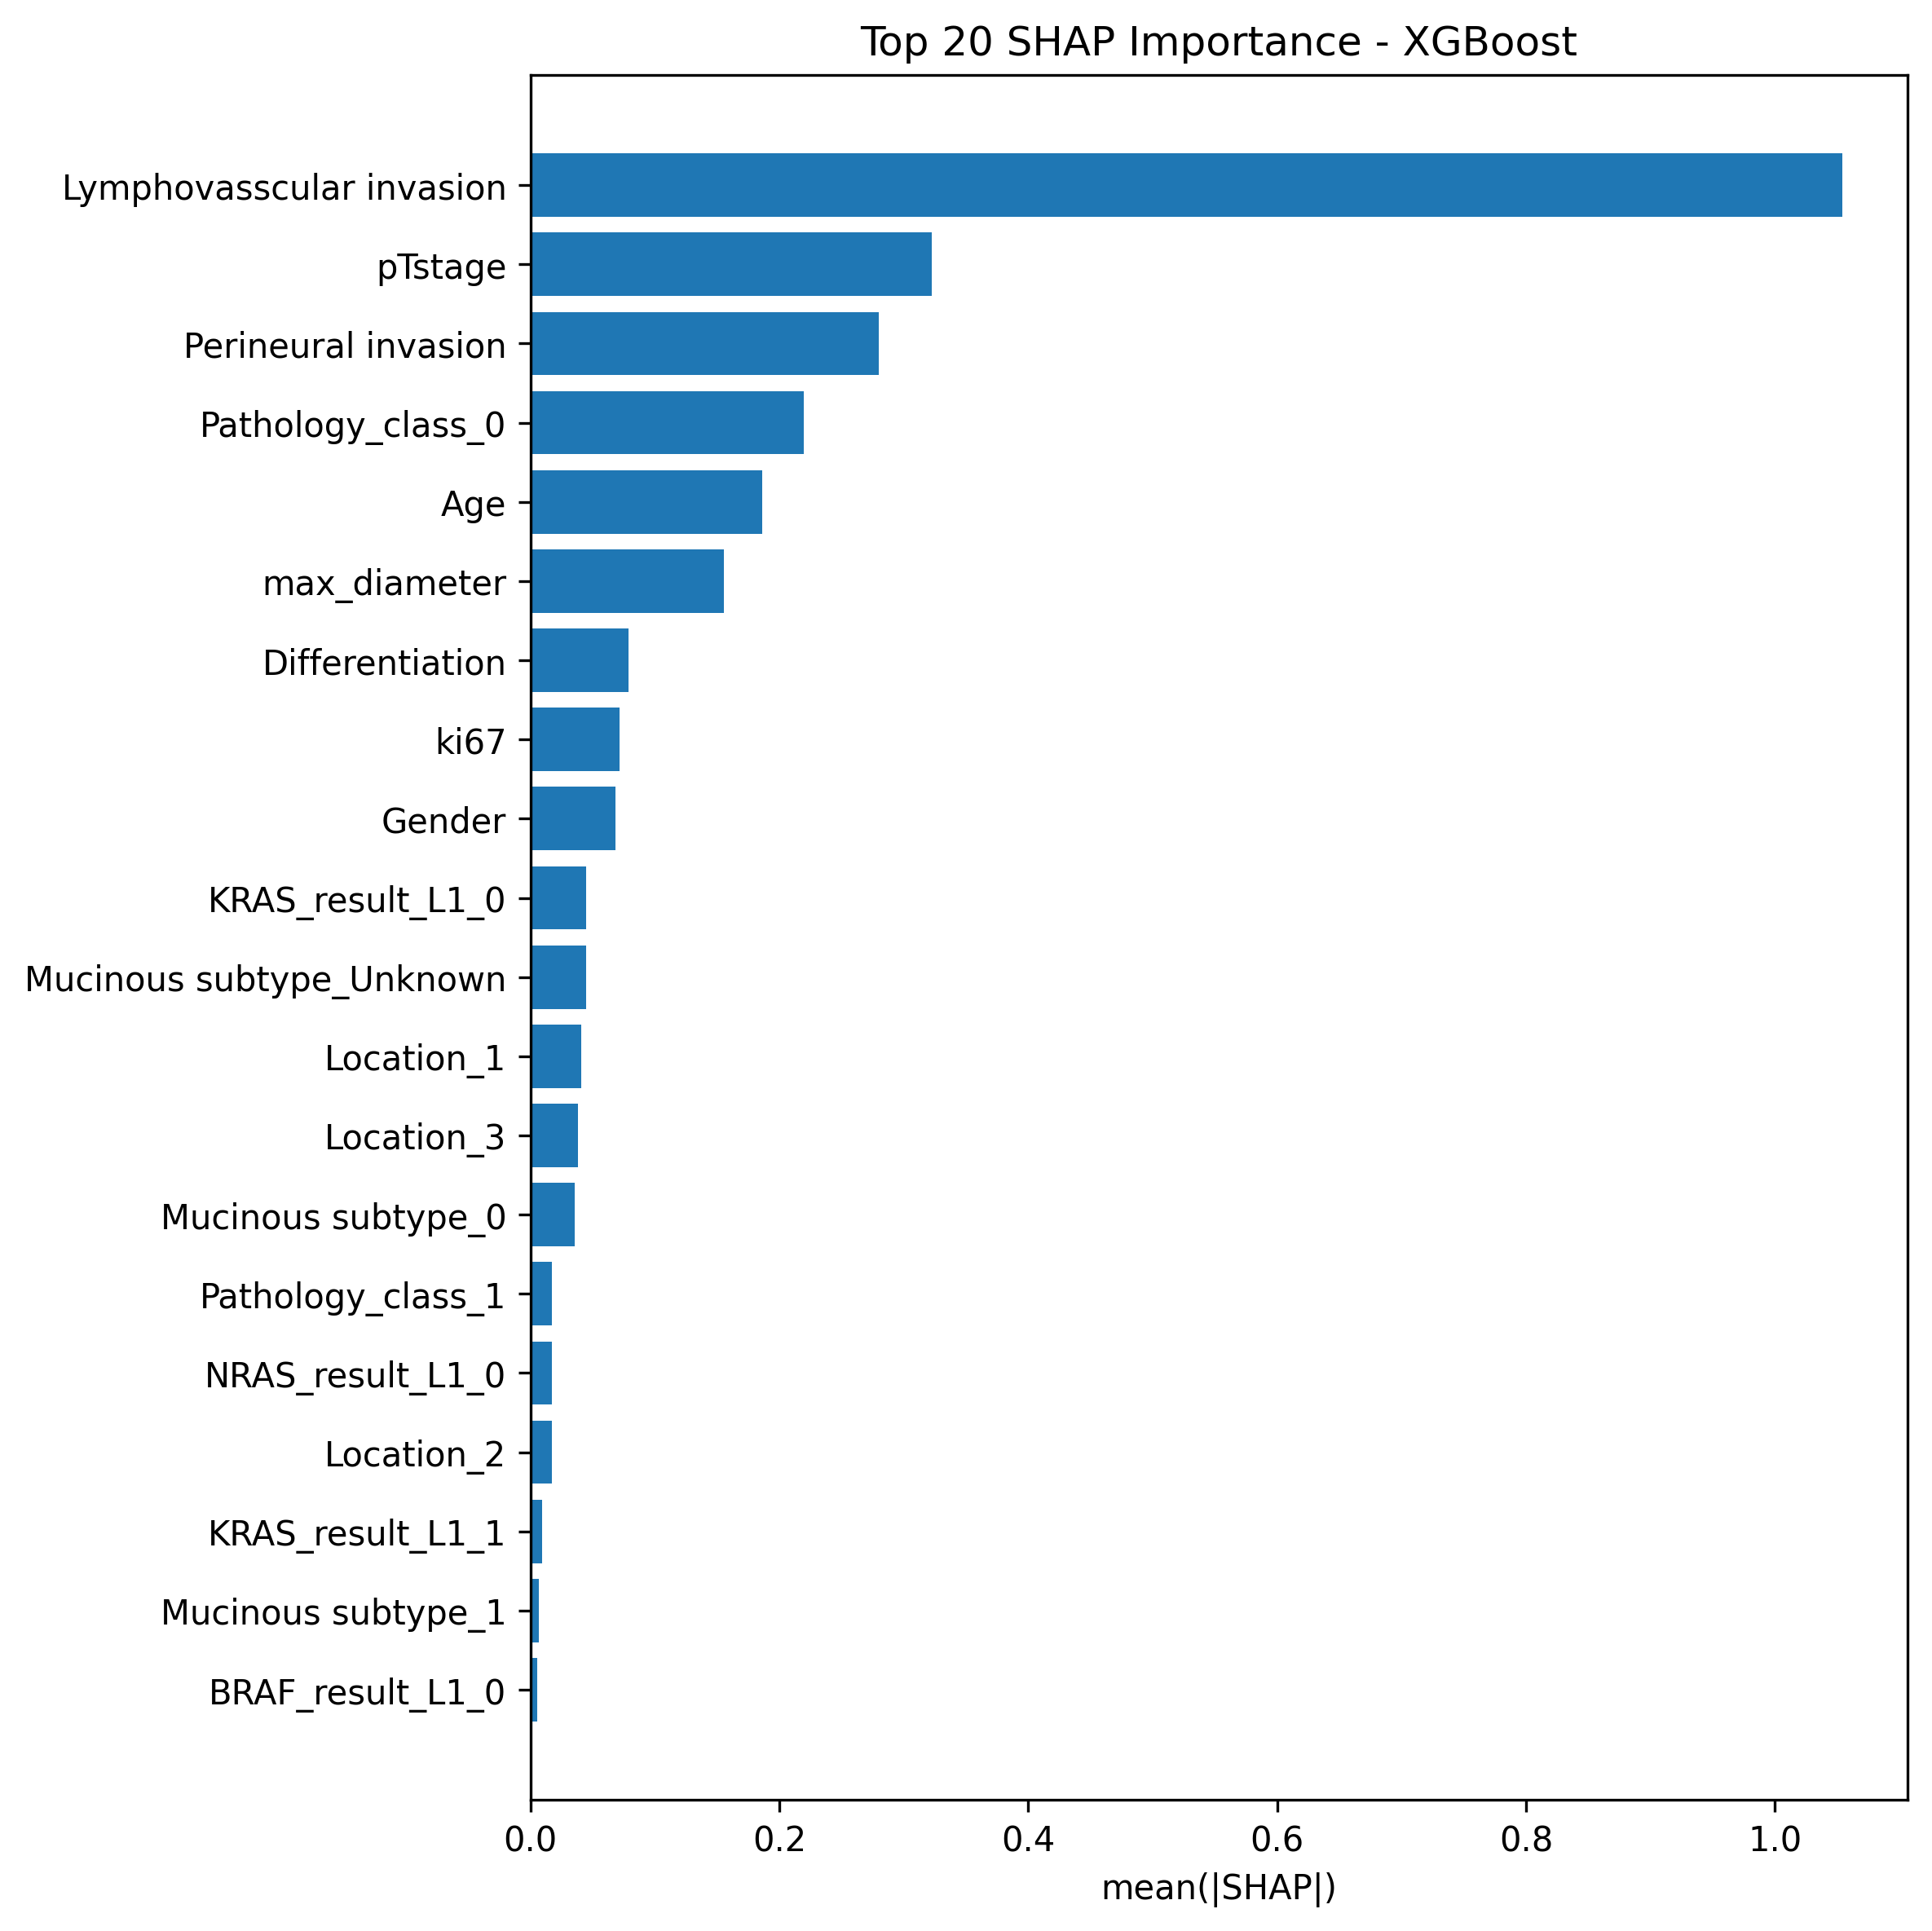

In [46]:
def make_shap_explanation(sample_idx):
    return shap.Explanation(
        values=shap_values[sample_idx],
        base_values=base_val,
        data=X_train.iloc[sample_idx, :].values,
        feature_names=X_train.columns.tolist()
    )


sample_idx = 0
sample_exp = make_shap_explanation(sample_idx)

plt.figure()
shap.plots.waterfall(sample_exp, max_display=20, show=False)
plt.tight_layout()
plt.savefig(
    f"{OUT_DIR}/{safe_name}_shap_waterfall_sample0.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

shap.initjs()

force_plot = shap.force_plot(
    base_value=base_val,
    shap_values=shap_values[sample_idx],
    features=X_train.iloc[sample_idx, :],
    feature_names=X_train.columns.tolist()
)

shap.save_html(
    f"{OUT_DIR}/{safe_name}_shap_force_sample0.html",
    force_plot
)

top20_shap = shap_imp.head(20).copy().sort_values("mean_abs_shap", ascending=True)

plt.figure(figsize=(8, 8), dpi=300)
plt.barh(top20_shap["Feature"], top20_shap["mean_abs_shap"])
plt.xlabel("mean(|SHAP|)")
plt.title(f"Top 20 SHAP Importance - {best_model_name}")
plt.tight_layout()
plt.savefig(
    f"{OUT_DIR}/{safe_name}_shap_importance_top20.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


In [47]:
feat = "max_diameter"

if feat not in X_train.columns:
    print(f"{feat} 不在 X_train 中")
else:
    feat_idx = X_train.columns.get_loc(feat)
    shap_feat = shap_values[:, feat_idx]

    pos_idx = int(shap_feat.argmax())
    neg_idx = int(shap_feat.argmin())

    for idx, tag in [(pos_idx, "posmax"), (neg_idx, "negmax")]:
        sample_exp = make_shap_explanation(idx)

        print(f"\n[{tag}] 样本索引: {idx}")
        print(f"{feat} 原始取值: {X_train.iloc[idx][feat]}")
        print(f"{feat} SHAP值: {shap_values[idx, feat_idx]:.6f}")

        plt.figure()
        shap.plots.waterfall(sample_exp, max_display=20, show=False)
        plt.tight_layout()
        plt.savefig(
            f"{OUT_DIR}/{safe_name}_shap_waterfall_{feat}_{tag}.pdf",
            dpi=300,
            bbox_inches="tight"
        )
        plt.close()

        X_train.iloc[[idx]].to_csv(
            f"{OUT_DIR}/{safe_name}_sample_{feat}_{tag}.csv",
            index=True,
            encoding="utf-8-sig"
        )


[posmax] 样本索引: 4777
max_diameter 原始取值: 0.9
max_diameter SHAP值: 1.714440

[negmax] 样本索引: 595
max_diameter 原始取值: 10.0
max_diameter SHAP值: -0.593697


<Figure size 640x480 with 0 Axes>

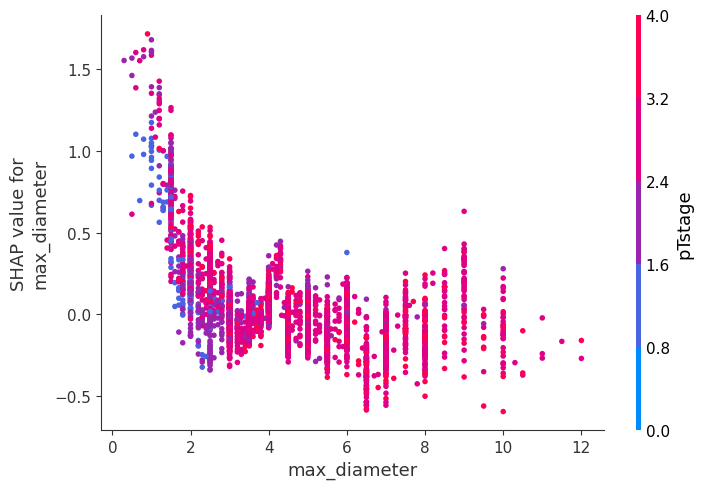

In [48]:
if {"max_diameter", "pTstage"}.issubset(X_train.columns):
    plt.figure()
    shap.dependence_plot(
        "max_diameter",
        shap_values,
        X_train,
        interaction_index="pTstage",
        show=False
    )
    plt.tight_layout()
    plt.savefig(
        f"{OUT_DIR}/{safe_name}_shap_interaction_max_diameter_pTstage.pdf",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()
else:
    print("max_diameter 或 pTstage 不在特征矩阵中，跳过该图。")

In [49]:
X_inter_base = X_train.copy()
n_features_total = X_inter_base.shape[1]

target_cells = 8_000_000
max_interaction_samples = int(target_cells / max(1, n_features_total ** 2))
max_interaction_samples = max(20, min(150, max_interaction_samples))
max_interaction_samples = min(max_interaction_samples, len(X_inter_base))

rng = np.random.RandomState(RANDOM_STATE)

if len(X_inter_base) > max_interaction_samples:
    sample_idx_inter = rng.choice(
        X_inter_base.index,
        size=max_interaction_samples,
        replace=False
    )
    X_inter = X_inter_base.loc[sample_idx_inter].copy()
else:
    X_inter = X_inter_base.copy()

if best_model_name == "XGBoost":
    dinter = xgb.DMatrix(X_inter, feature_names=X_inter.columns.tolist())
    shap_interaction_full = best_model.get_booster().predict(
        dinter,
        pred_interactions=True
    )
    shap_interaction_full = np.asarray(shap_interaction_full)

    if shap_interaction_full.shape[1] == X_inter.shape[1] + 1:
        shap_interaction_values = shap_interaction_full[:, :-1, :-1]
    else:
        shap_interaction_values = shap_interaction_full

else:
    try:
        inter_explainer = shap.TreeExplainer(best_model)
        shap_interaction_full = inter_explainer.shap_interaction_values(X_inter)

        if isinstance(shap_interaction_full, list):
            shap_interaction_full = (
                shap_interaction_full[1]
                if len(shap_interaction_full) > 1
                else shap_interaction_full[0]
            )

        shap_interaction_values = np.asarray(shap_interaction_full)

    except Exception as e:
        raise RuntimeError(
            f"{best_model_name} 当前无法稳定计算 SHAP interaction values。"
            f"原始错误: {e}"
        )

feature_names_inter = X_inter.columns.tolist()

In [50]:
signed_interaction_mean = shap_interaction_values.mean(axis=0)
abs_interaction_mean = np.abs(shap_interaction_values).mean(axis=0)

positive_ratio = (shap_interaction_values > 0).mean(axis=0)
negative_ratio = (shap_interaction_values < 0).mean(axis=0)

signed_interaction_df = pd.DataFrame(
    signed_interaction_mean,
    index=feature_names_inter,
    columns=feature_names_inter
)

abs_interaction_df = pd.DataFrame(
    abs_interaction_mean,
    index=feature_names_inter,
    columns=feature_names_inter
)

positive_ratio_df = pd.DataFrame(
    positive_ratio,
    index=feature_names_inter,
    columns=feature_names_inter
)

negative_ratio_df = pd.DataFrame(
    negative_ratio,
    index=feature_names_inter,
    columns=feature_names_inter
)

main_effect_mean_abs = np.abs(
    np.array([
        np.diag(shap_interaction_values[i])
        for i in range(shap_interaction_values.shape[0])
    ])
).mean(axis=0)

main_effect_df = (
    pd.DataFrame({
        "Feature": feature_names_inter,
        "main_effect_mean_abs": main_effect_mean_abs
    })
    .sort_values("main_effect_mean_abs", ascending=False)
    .reset_index(drop=True)
)

signed_interaction_df.to_csv(
    f"{NETWORK_DIR}/{safe_name}_interaction_signed_mean_matrix.csv",
    encoding="utf-8-sig"
)

abs_interaction_df.to_csv(
    f"{NETWORK_DIR}/{safe_name}_interaction_abs_mean_matrix.csv",
    encoding="utf-8-sig"
)

positive_ratio_df.to_csv(
    f"{NETWORK_DIR}/{safe_name}_interaction_positive_ratio_matrix.csv",
    encoding="utf-8-sig"
)

negative_ratio_df.to_csv(
    f"{NETWORK_DIR}/{safe_name}_interaction_negative_ratio_matrix.csv",
    encoding="utf-8-sig"
)

main_effect_df.to_csv(
    f"{NETWORK_DIR}/{safe_name}_main_effect_mean_abs.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n主效应 Top 20:")
print(main_effect_df.head(20))


主效应 Top 20:
                     Feature  main_effect_mean_abs
0   Lymphovasscular invasion              1.111709
1                    pTstage              0.313473
2        Perineural invasion              0.294092
3          Pathology_class_0              0.215285
4                        Age              0.146079
5               max_diameter              0.137462
6            Differentiation              0.079617
7                     Gender              0.063656
8                       ki67              0.056354
9   Mucinous subtype_Unknown              0.043994
10                Location_1              0.040039
11                Location_3              0.034053
12        Mucinous subtype_0              0.031224
13          KRAS_result_L1_0              0.018958
14          NRAS_result_L1_0              0.017702
15         Pathology_class_1              0.016886
16        Mucinous subtype_1              0.010040
17          KRAS_result_L1_1              0.007937
18                

In [51]:
top_n_nodes = 15
top_n_edges = 25

top_features_nodes = [
    f for f in shap_imp["Feature"].tolist()
    if f in feature_names_inter
][:top_n_nodes]

node_df = shap_imp[shap_imp["Feature"].isin(top_features_nodes)].copy()
node_df = node_df.set_index("Feature").loc[top_features_nodes].reset_index()
node_df.columns = ["Feature", "mean_abs_shap"]

edge_records = []

for f1, f2 in itertools.combinations(top_features_nodes, 2):
    mean_abs_val = abs_interaction_df.loc[f1, f2]
    mean_signed_val = signed_interaction_df.loc[f1, f2]
    pos_ratio_val = positive_ratio_df.loc[f1, f2]
    neg_ratio_val = negative_ratio_df.loc[f1, f2]

    sign_consistency = abs(mean_signed_val) / (mean_abs_val + 1e-12)

    if mean_signed_val > 0:
        sign_label = "positive"
    elif mean_signed_val < 0:
        sign_label = "negative"
    else:
        sign_label = "neutral"

    edge_records.append({
        "feature_1": f1,
        "feature_2": f2,
        "interaction_strength": mean_abs_val,
        "interaction_signed_mean": mean_signed_val,
        "positive_ratio": pos_ratio_val,
        "negative_ratio": neg_ratio_val,
        "sign_consistency": sign_consistency,
        "sign_label": sign_label
    })

edge_df = (
    pd.DataFrame(edge_records)
    .sort_values("interaction_strength", ascending=False)
)

edge_df = edge_df[edge_df["interaction_strength"] > 0].head(top_n_edges).copy()

node_df.to_csv(
    f"{NETWORK_DIR}/{safe_name}_network_nodes_signed.csv",
    index=False,
    encoding="utf-8-sig"
)

edge_df.to_csv(
    f"{NETWORK_DIR}/{safe_name}_network_edges_signed.csv",
    index=False,
    encoding="utf-8-sig"
)

interaction_top_signed_df = signed_interaction_df.loc[
    top_features_nodes,
    top_features_nodes
].copy()

interaction_top_signed_df.to_csv(
    f"{NETWORK_DIR}/{safe_name}_interaction_matrix_top_signed.csv",
    encoding="utf-8-sig"
)

print("\nTop nodes:")
print(node_df)

print("\nTop signed edges:")
print(edge_df.head(20))


Top nodes:
                     Feature  mean_abs_shap
0   Lymphovasscular invasion       1.053784
1                    pTstage       0.322374
2        Perineural invasion       0.279697
3          Pathology_class_0       0.219683
4                        Age       0.186329
5               max_diameter       0.155825
6            Differentiation       0.078820
7                       ki67       0.071920
8                     Gender       0.068221
9           KRAS_result_L1_0       0.044757
10  Mucinous subtype_Unknown       0.044726
11                Location_1       0.040864
12                Location_3       0.038520
13        Mucinous subtype_0       0.035878
14         Pathology_class_1       0.017655

Top signed edges:
                   feature_1            feature_2  interaction_strength  \
4   Lymphovasscular invasion         max_diameter              0.059131   
50                       Age         max_diameter              0.048677   
17                   pTstage         max

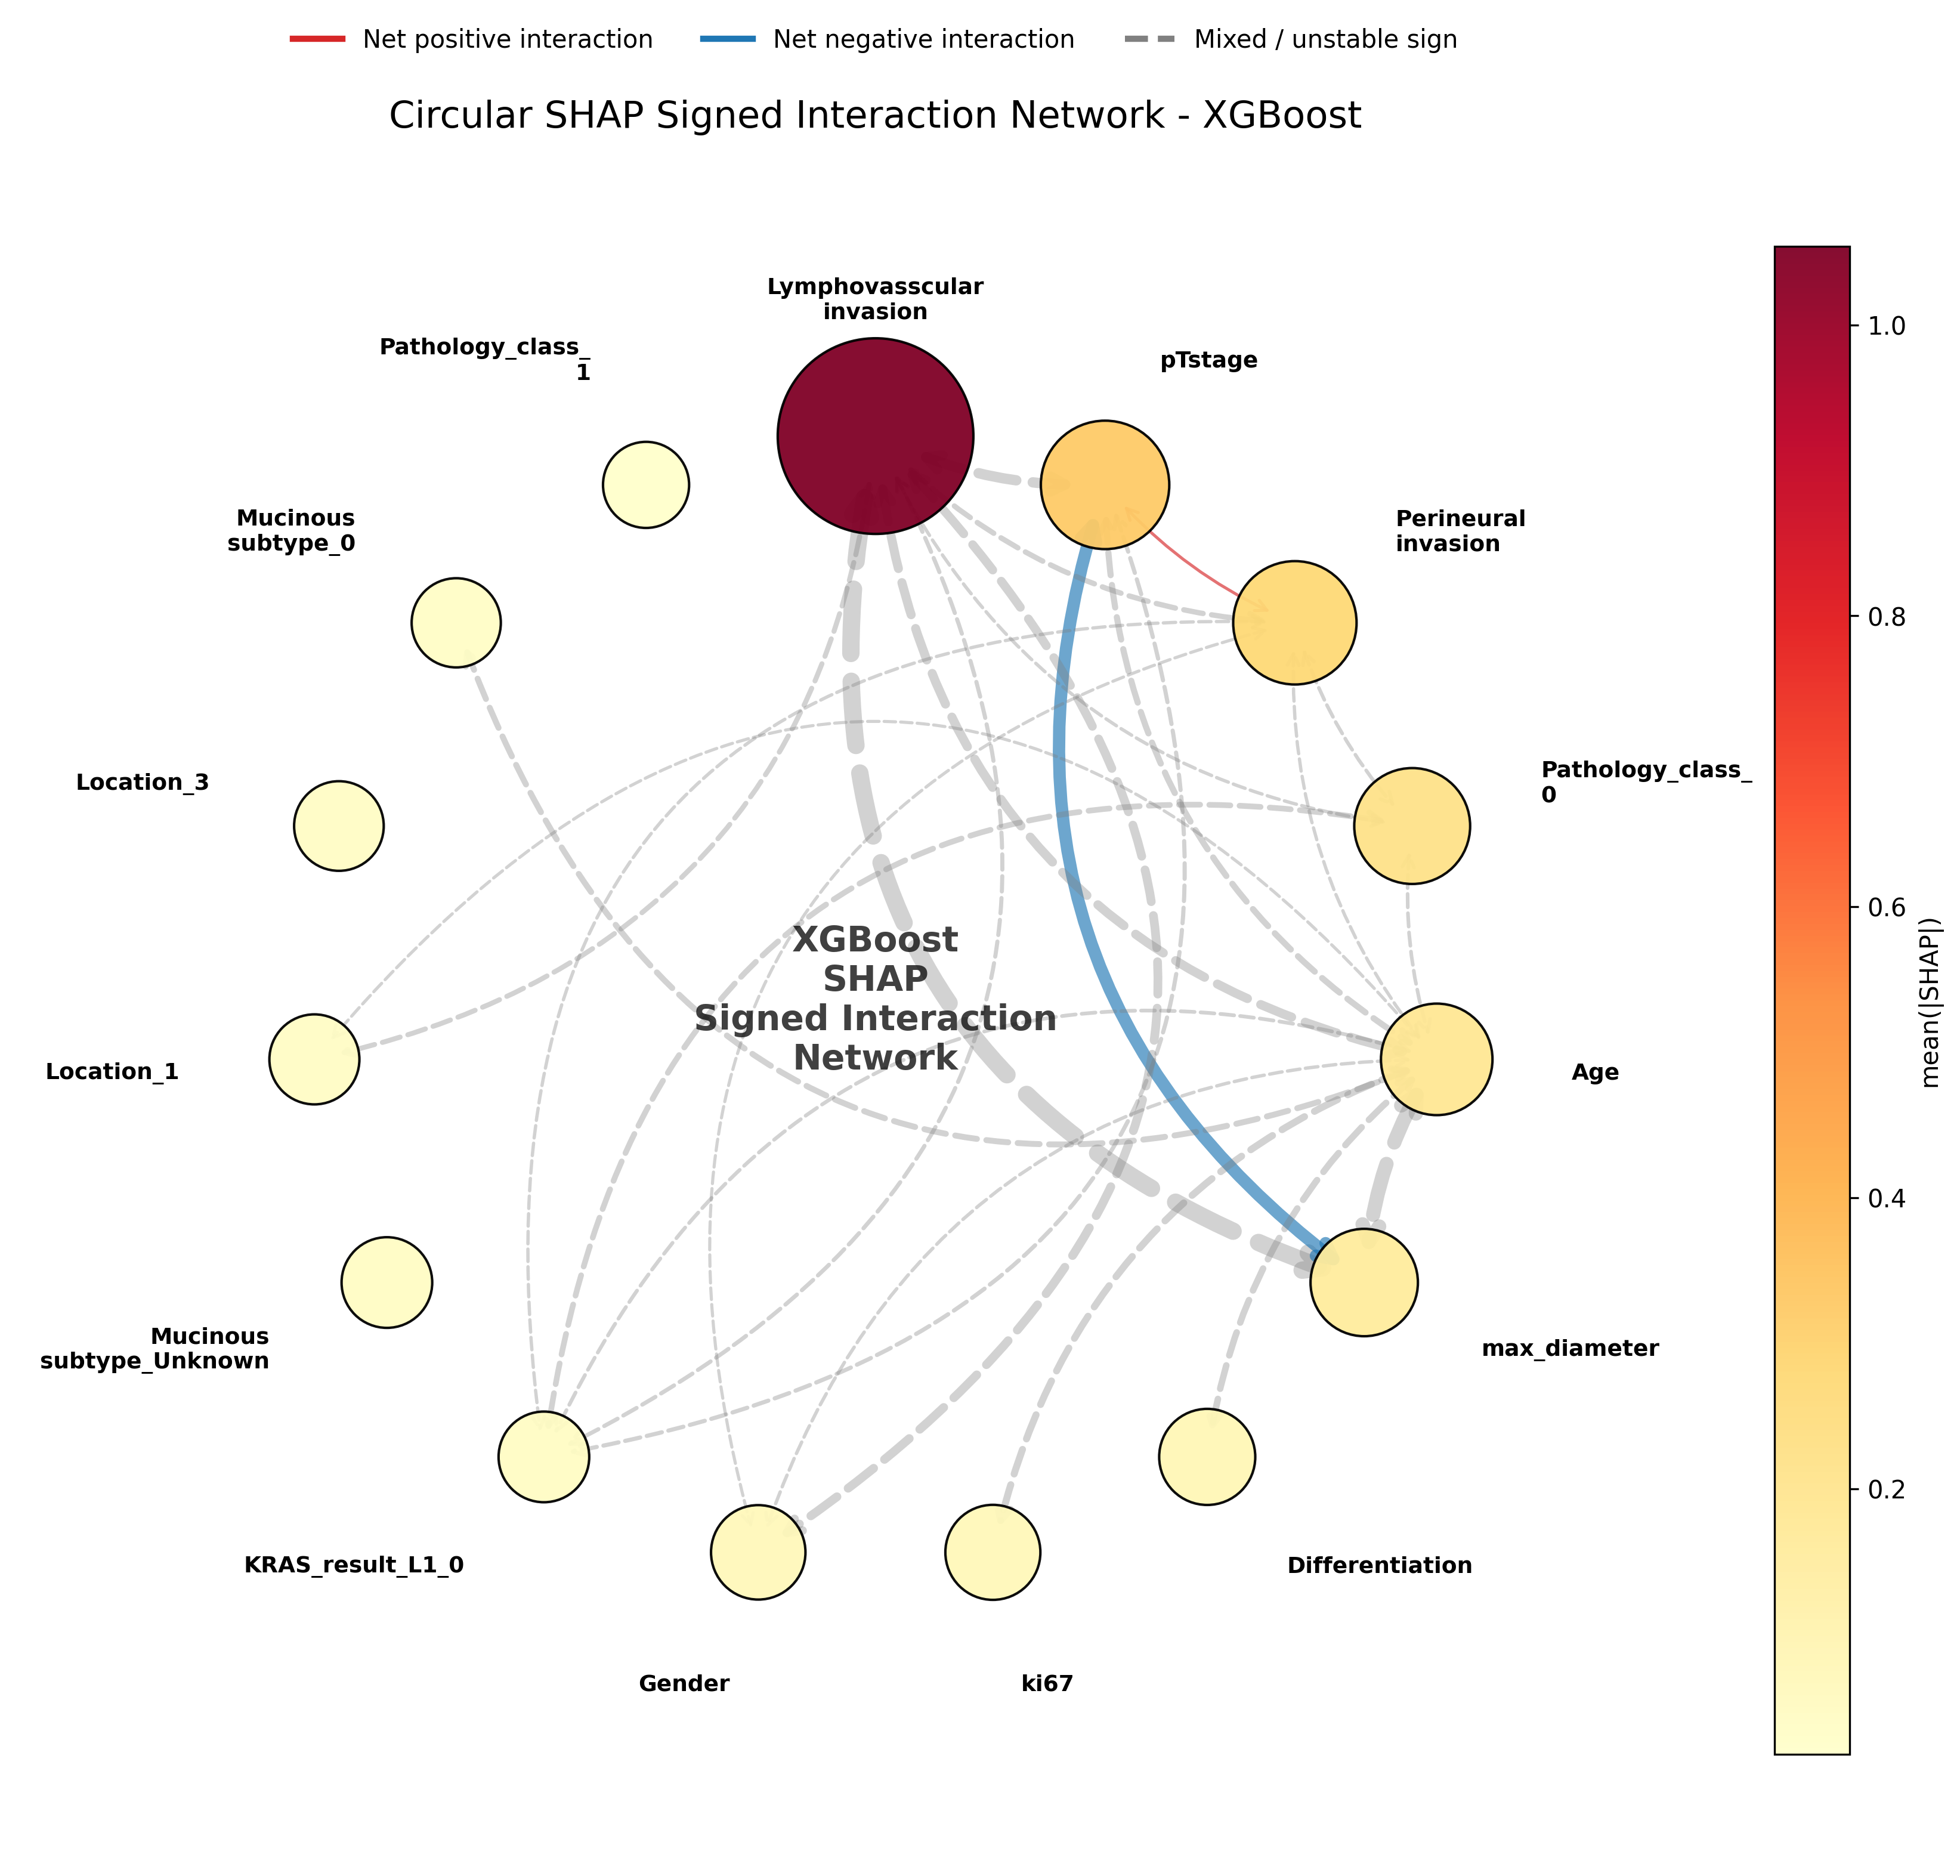

圆形 SHAP signed interaction network 已输出到 outs_model_compare/shap_interaction_network/


In [52]:
def wrap_label(s, width=16):
    s = str(s)
    return "\n".join(textwrap.wrap(s, width=width)) if len(s) > width else s


def scale_values(values, out_min, out_max):
    values = np.asarray(values, dtype=float)

    if len(values) <= 1 or values.max() == values.min():
        return np.repeat((out_min + out_max) / 2, len(values))

    return out_min + (out_max - out_min) * (
        (values - values.min()) / (values.max() - values.min())
    )


def get_arc_rad(i, j, n):
    step = (j - i) % n

    if step == 0:
        return 0.0

    short_dist = min(step, n - step)
    max_short = max(1, n // 2)
    mag = 0.12 + 0.48 * (short_dist - 1) / max(1, max_short - 1)
    sign = 1 if step <= n / 2 else -1

    return sign * mag


def get_edge_style(row, consistency_thr=0.25):
    if row["sign_consistency"] < consistency_thr:
        return "gray", "--", 0.35
    if row["interaction_signed_mean"] > 0:
        return "#d62728", "-", 0.65
    return "#1f77b4", "-", 0.65


if node_df.empty:
    print("网络图未生成：没有可用节点。")
else:
    plot_node_df = node_df.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    feature_order = plot_node_df["Feature"].tolist()
    n_nodes = len(feature_order)

    angles = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi, n_nodes, endpoint=False)
    pos = {
        feat: (np.cos(theta), np.sin(theta))
        for feat, theta in zip(feature_order, angles)
    }

    order_map = {feat: i for i, feat in enumerate(feature_order)}
    angle_map = dict(zip(feature_order, angles))

    node_importance = plot_node_df["mean_abs_shap"].values.astype(float)
    node_sizes = scale_values(node_importance, 1200, 6200)

    node_size_map = dict(zip(feature_order, node_sizes))
    node_value_map = dict(zip(feature_order, node_importance))

    node_norm = colors.Normalize(
        vmin=node_importance.min(),
        vmax=node_importance.max() if node_importance.max() > node_importance.min()
        else node_importance.min() + 1e-9
    )

    plot_edge_df = edge_df.copy()

    if not plot_edge_df.empty:
        plot_edge_df["plot_width"] = scale_values(
            plot_edge_df["interaction_strength"].values,
            1.2,
            7.0
        )

    fig, ax = plt.subplots(figsize=(12, 12), dpi=300)

    for _, row in plot_edge_df.iterrows():
        f1 = row["feature_1"]
        f2 = row["feature_2"]

        if f1 not in pos or f2 not in pos:
            continue

        x1, y1 = pos[f1]
        x2, y2 = pos[f2]

        rad = get_arc_rad(order_map[f1], order_map[f2], n_nodes)
        color, linestyle, alpha = get_edge_style(row)

        patch = FancyArrowPatch(
            posA=(x1, y1),
            posB=(x2, y2),
            arrowstyle="<->",
            connectionstyle=f"arc3,rad={rad}",
            linewidth=row["plot_width"],
            linestyle=linestyle,
            color=color,
            alpha=alpha,
            shrinkA=max(10, np.sqrt(node_size_map[f1]) * 0.22),
            shrinkB=max(10, np.sqrt(node_size_map[f2]) * 0.22),
            mutation_scale=10 + row["plot_width"] * 1.2,
            zorder=1
        )

        ax.add_patch(patch)

    xs = [pos[f][0] for f in feature_order]
    ys = [pos[f][1] for f in feature_order]
    cs = [node_value_map[f] for f in feature_order]
    ss = [node_size_map[f] for f in feature_order]

    sc = ax.scatter(
        xs,
        ys,
        s=ss,
        c=cs,
        cmap=plt.cm.YlOrRd,
        norm=node_norm,
        edgecolors="black",
        linewidths=1.0,
        alpha=0.95,
        zorder=3
    )

    label_radius = 1.24

    for feat in feature_order:
        theta = angle_map[feat]
        x = label_radius * np.cos(theta)
        y = label_radius * np.sin(theta)

        if np.cos(theta) > 0.15:
            ha = "left"
        elif np.cos(theta) < -0.15:
            ha = "right"
        else:
            ha = "center"

        ax.text(
            x,
            y,
            wrap_label(feat),
            fontsize=9,
            fontweight="bold",
            ha=ha,
            va="center",
            zorder=4
        )

    ax.text(
        0,
        0,
        f"{best_model_name}\nSHAP\nSigned Interaction\nNetwork",
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        alpha=0.75
    )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.72, pad=0.02)
    cbar.set_label("mean(|SHAP|)")

    legend_handles = [
        Line2D([0], [0], color="#d62728", lw=2.5, linestyle="-", label="Net positive interaction"),
        Line2D([0], [0], color="#1f77b4", lw=2.5, linestyle="-", label="Net negative interaction"),
        Line2D([0], [0], color="gray", lw=2.5, linestyle="--", label="Mixed / unstable sign")
    ]

    ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.08),
        ncol=3,
        frameon=False
    )

    ax.set_title(f"Circular SHAP Signed Interaction Network - {best_model_name}", fontsize=15)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-1.52, 1.52)
    ax.set_ylim(-1.52, 1.52)

    plt.tight_layout()
    plt.savefig(
        f"{NETWORK_DIR}/{safe_name}_signed_interaction_network_circular.pdf",
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        f"{NETWORK_DIR}/{safe_name}_signed_interaction_network_circular.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

print(f"圆形 SHAP signed interaction network 已输出到 {NETWORK_DIR}/")

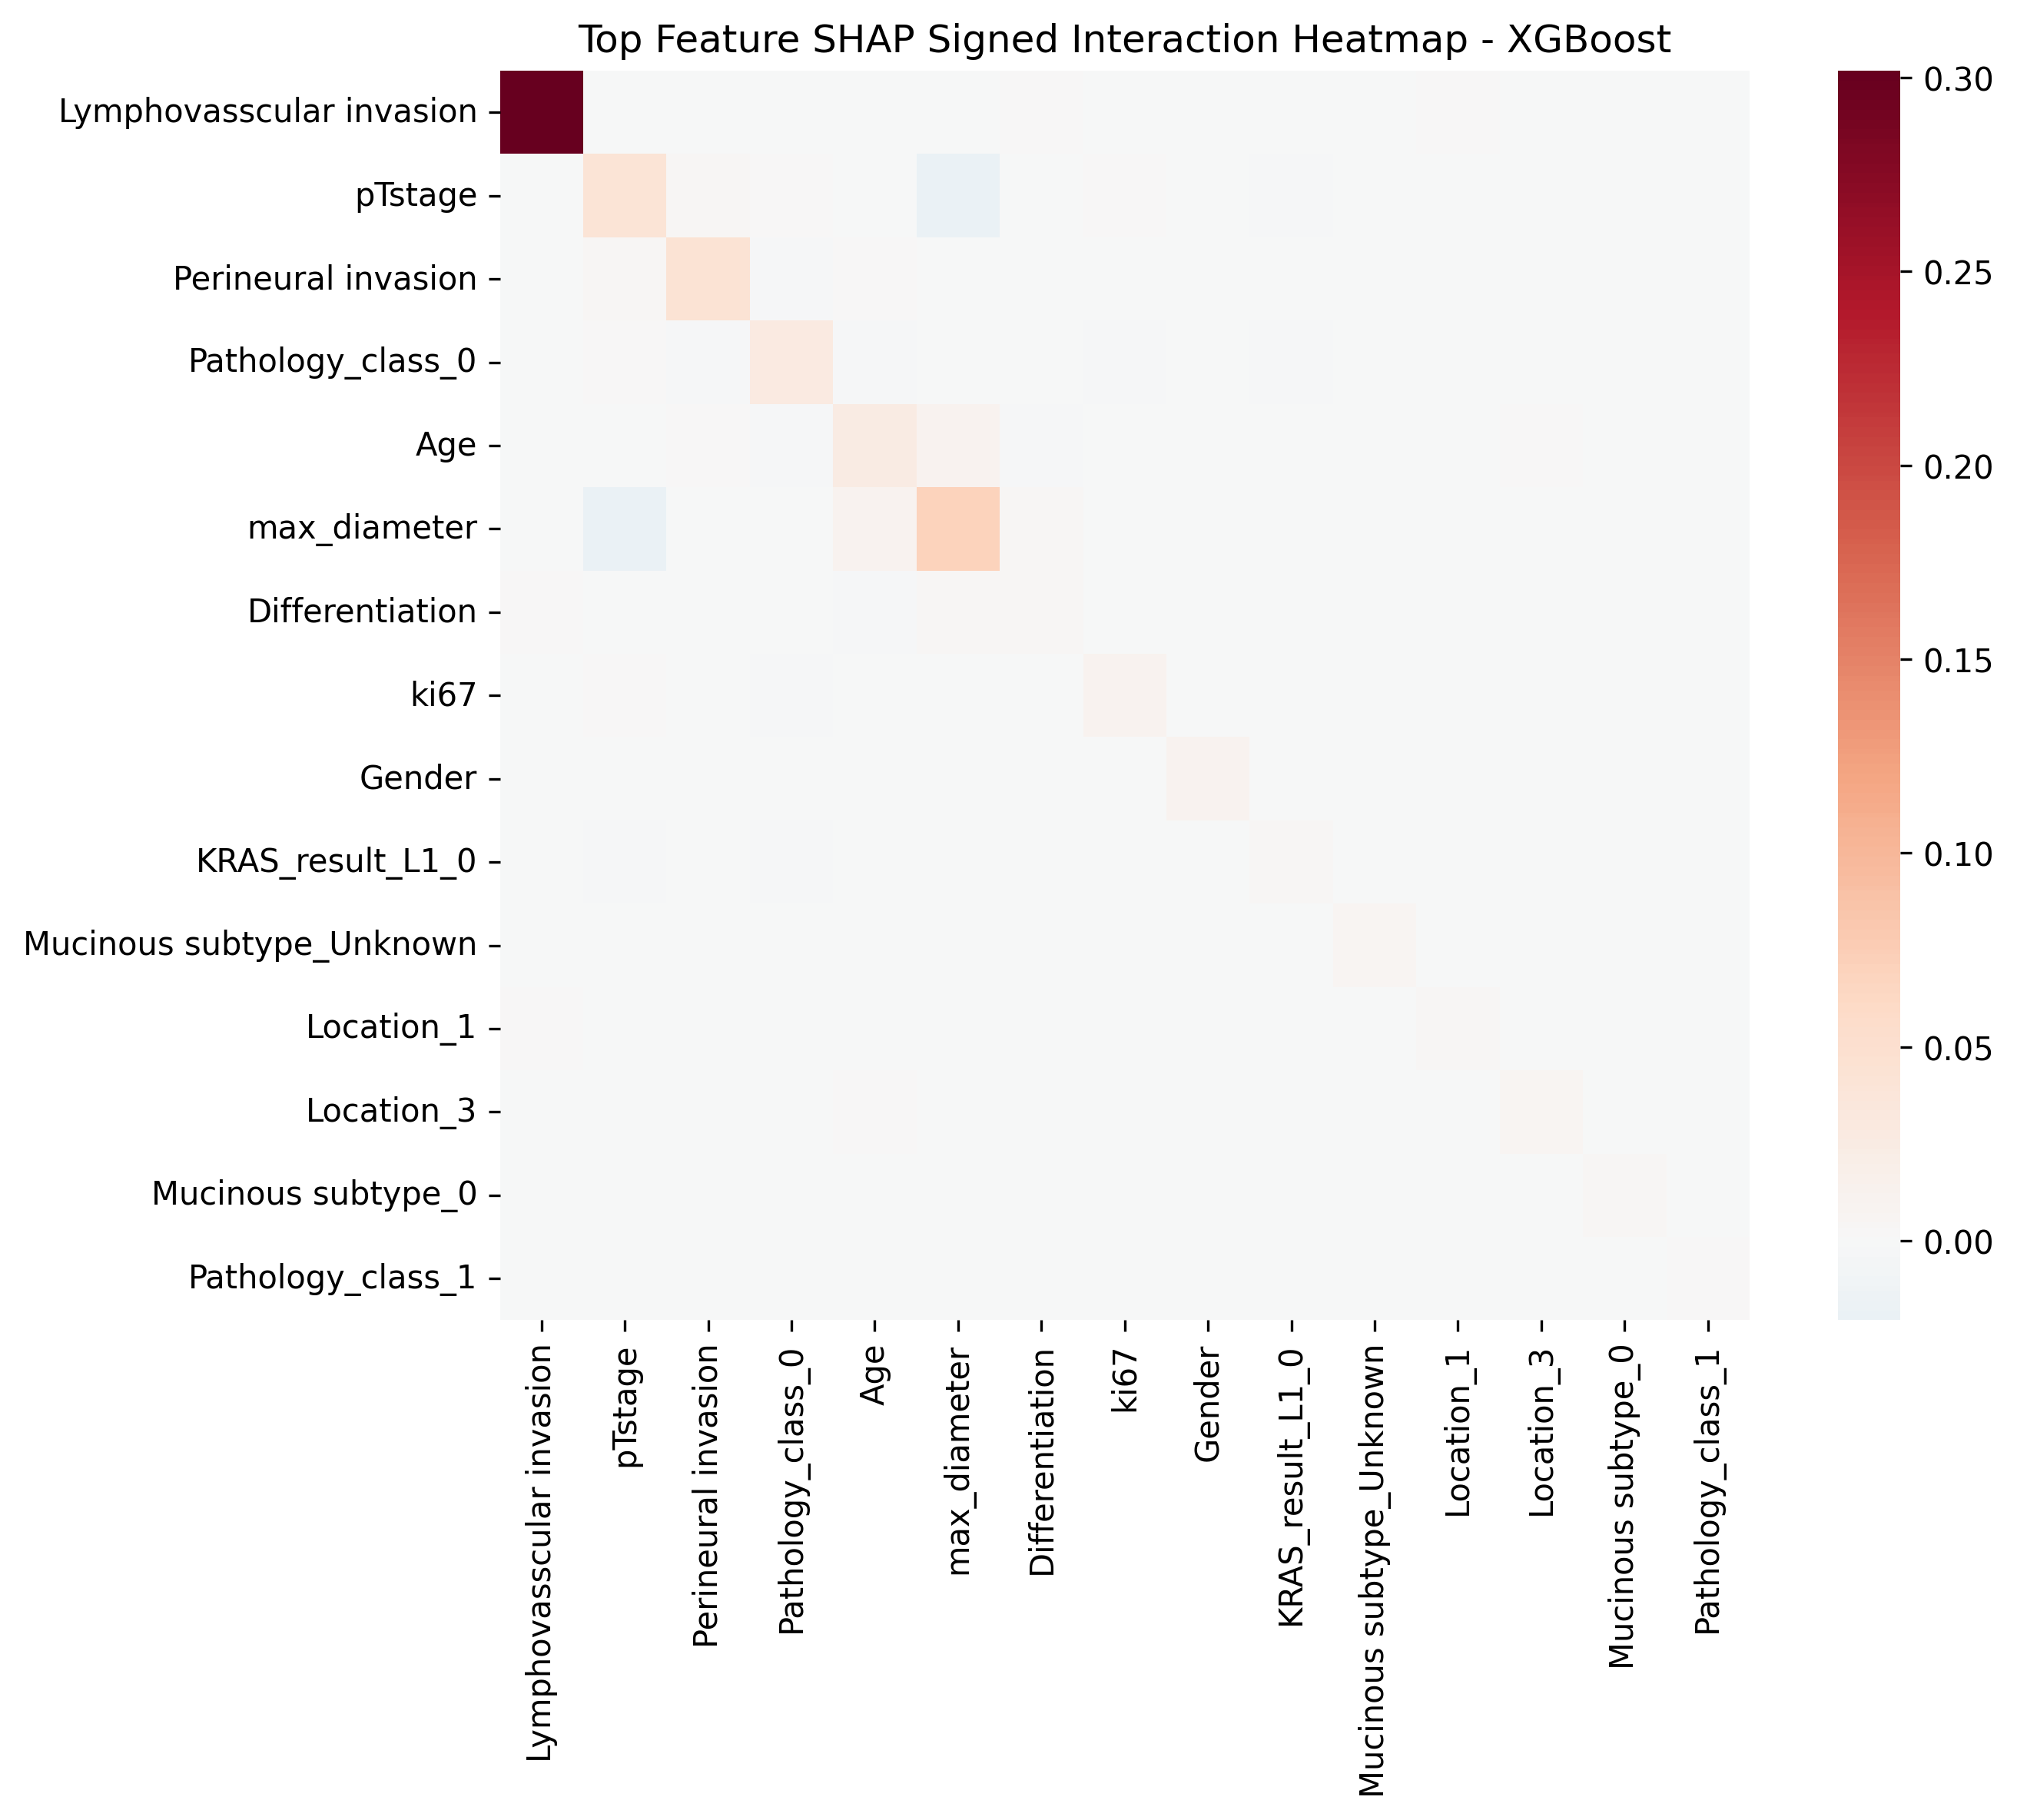

In [53]:
plt.figure(figsize=(10, 8), dpi=300)

sns.heatmap(
    interaction_top_signed_df,
    cmap="RdBu_r",
    center=0,
    square=True
)

plt.title(f"Top Feature SHAP Signed Interaction Heatmap - {best_model_name}")
plt.tight_layout()
plt.savefig(
    f"{NETWORK_DIR}/{safe_name}_signed_interaction_heatmap_top_features.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

In [54]:
top_n_pool_for_pairs = 30

top_features_pool = [
    f for f in shap_imp["Feature"].tolist()
    if f in feature_names_inter
][:top_n_pool_for_pairs]

manual_pdp_pairs = [
    ("pTstage", "max_diameter"),
    ("Age", "Differentiation")
]

manual_pdp_pairs = [
    (f1, f2)
    for f1, f2 in manual_pdp_pairs
    if f1 in X_train.columns and f2 in X_train.columns
]

pair_records = []

for f1, f2 in itertools.combinations(top_features_pool, 2):
    pair_records.append({
        "feature_1": f1,
        "feature_2": f2,
        "interaction_strength": abs_interaction_df.loc[f1, f2],
        "interaction_signed_mean": signed_interaction_df.loc[f1, f2],
        "nunique_1": X_train[f1].nunique(dropna=False),
        "nunique_2": X_train[f2].nunique(dropna=False)
    })

pair_df = (
    pd.DataFrame(pair_records)
    .sort_values("interaction_strength", ascending=False)
)

pair_df.to_csv(
    f"{PDP_DIR}/{safe_name}_pdp_pair_candidates_ranked.csv",
    index=False,
    encoding="utf-8-sig"
)

if manual_pdp_pairs:
    selected_pair_df = pd.DataFrame(
        manual_pdp_pairs,
        columns=["feature_1", "feature_2"]
    )

    selected_pair_df["interaction_strength"] = selected_pair_df.apply(
        lambda r: abs_interaction_df.loc[r["feature_1"], r["feature_2"]],
        axis=1
    )

    selected_pair_df["interaction_signed_mean"] = selected_pair_df.apply(
        lambda r: signed_interaction_df.loc[r["feature_1"], r["feature_2"]],
        axis=1
    )

    selected_pair_df["nunique_1"] = selected_pair_df["feature_1"].map(
        lambda c: X_train[c].nunique(dropna=False)
    )

    selected_pair_df["nunique_2"] = selected_pair_df["feature_2"].map(
        lambda c: X_train[c].nunique(dropna=False)
    )

else:
    n_pdp_pairs = 6

    selected_pair_df = pair_df[
        (pair_df["nunique_1"] >= 4) &
        (pair_df["nunique_2"] >= 4)
    ].head(n_pdp_pairs).copy()

    if selected_pair_df.empty:
        selected_pair_df = pair_df[
            (pair_df["nunique_1"] >= 2) &
            (pair_df["nunique_2"] >= 2)
        ].head(n_pdp_pairs).copy()

if selected_pair_df.empty:
    raise ValueError("没有找到可用于二维 PDP 的特征对。")

selected_pair_df.to_csv(
    f"{PDP_DIR}/{safe_name}_pdp_selected_pairs.csv",
    index=False,
    encoding="utf-8-sig"
)


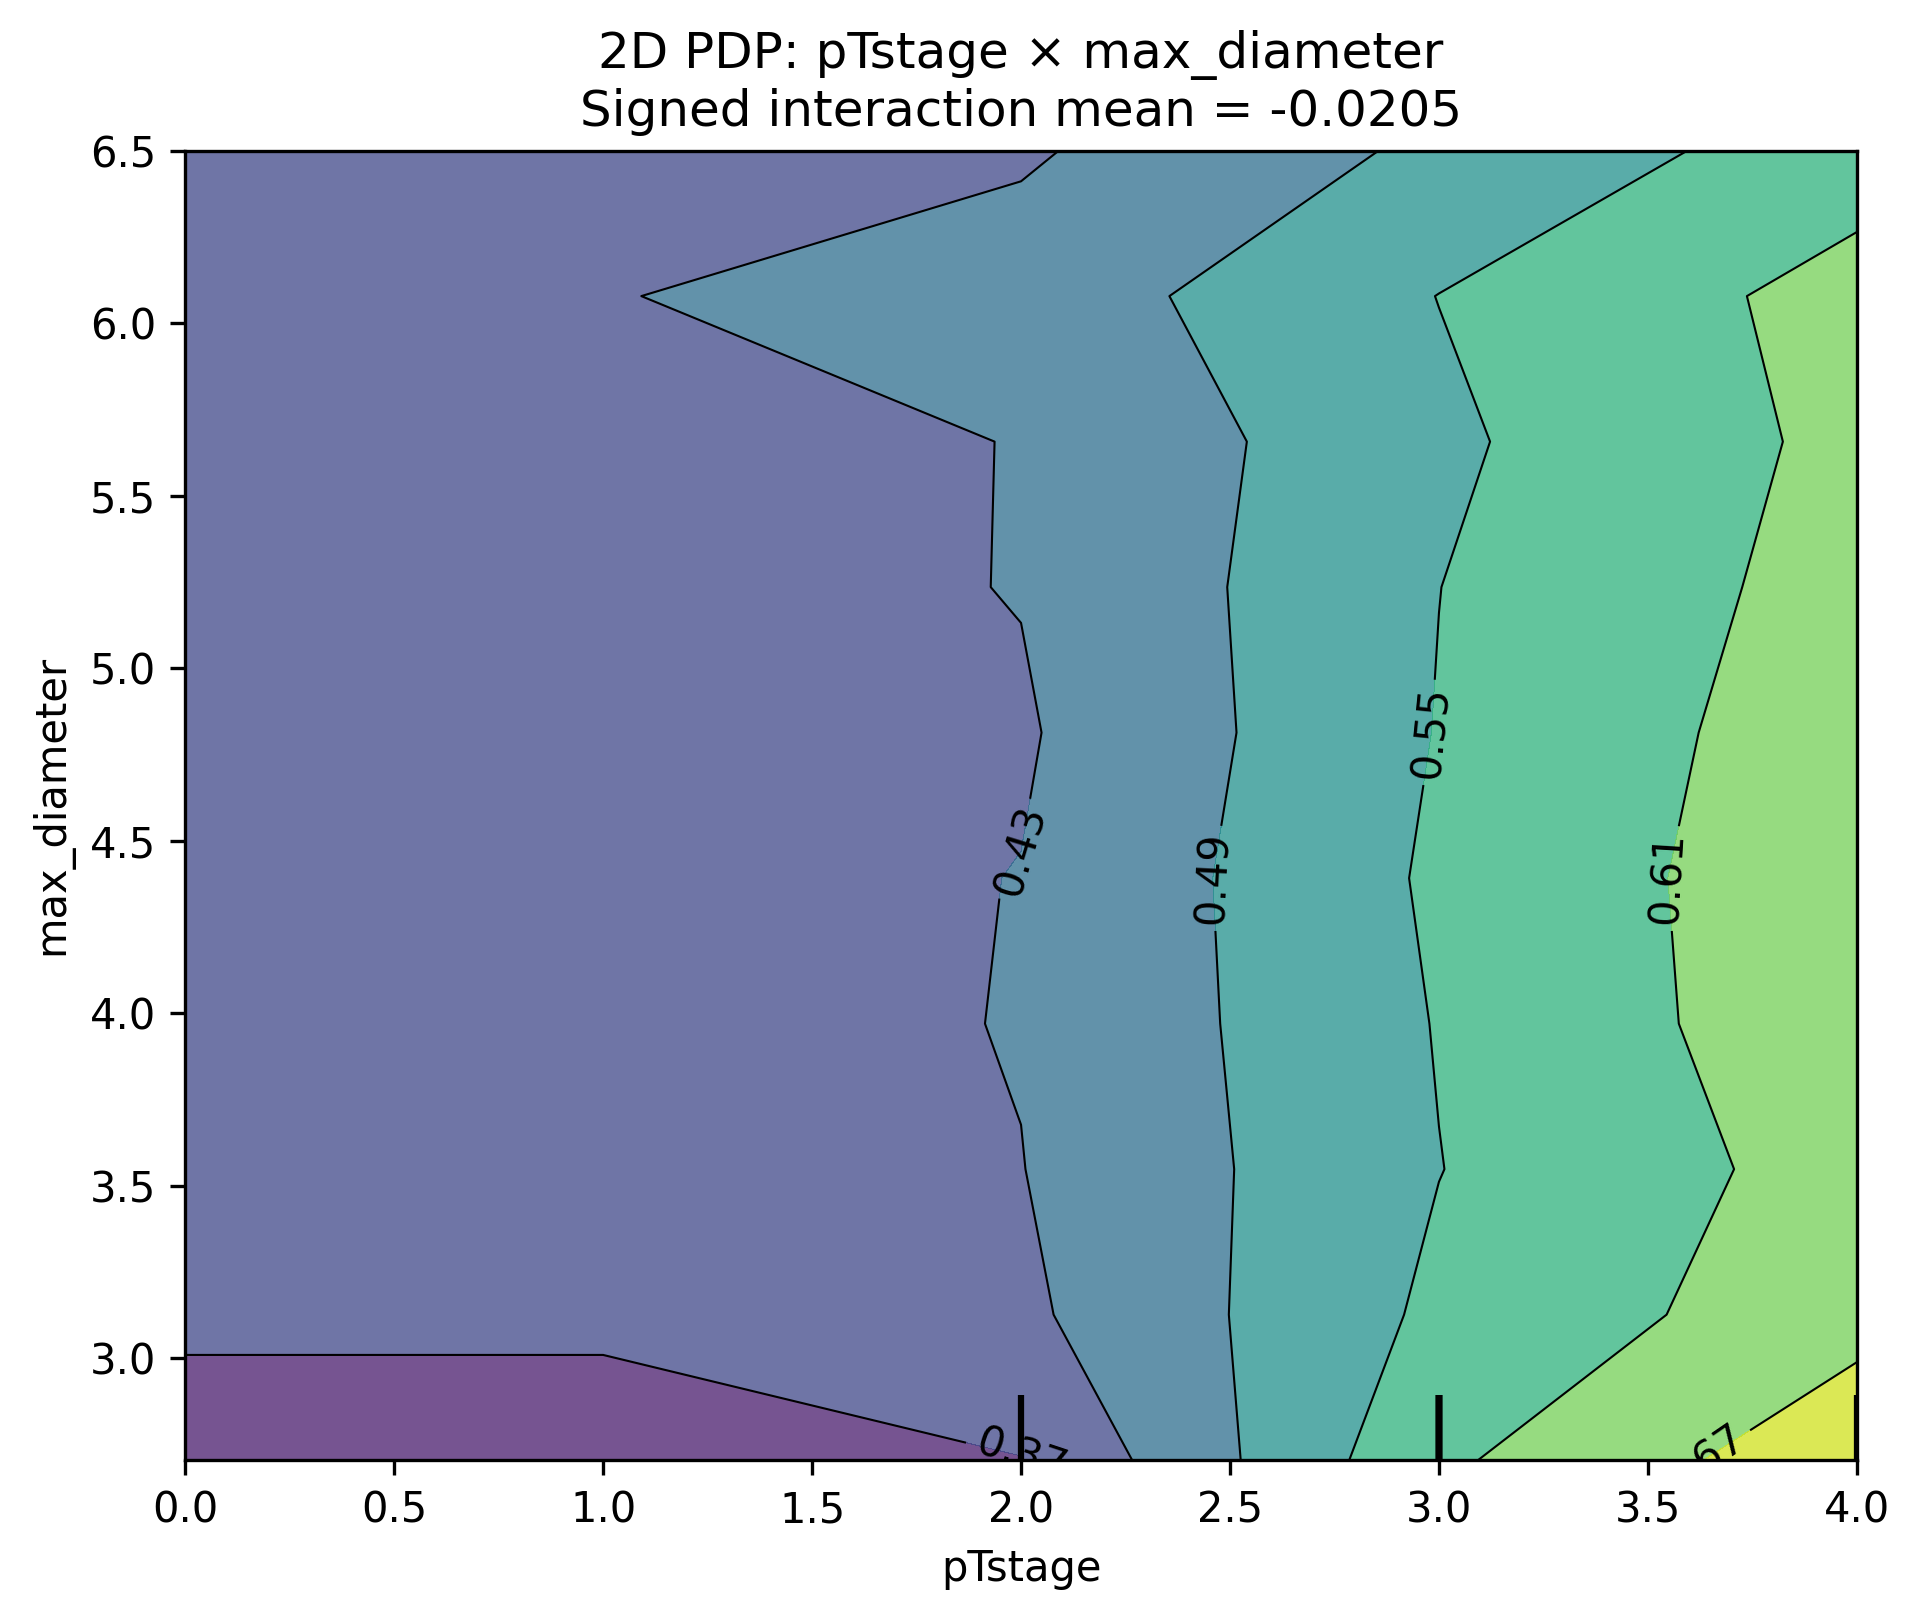

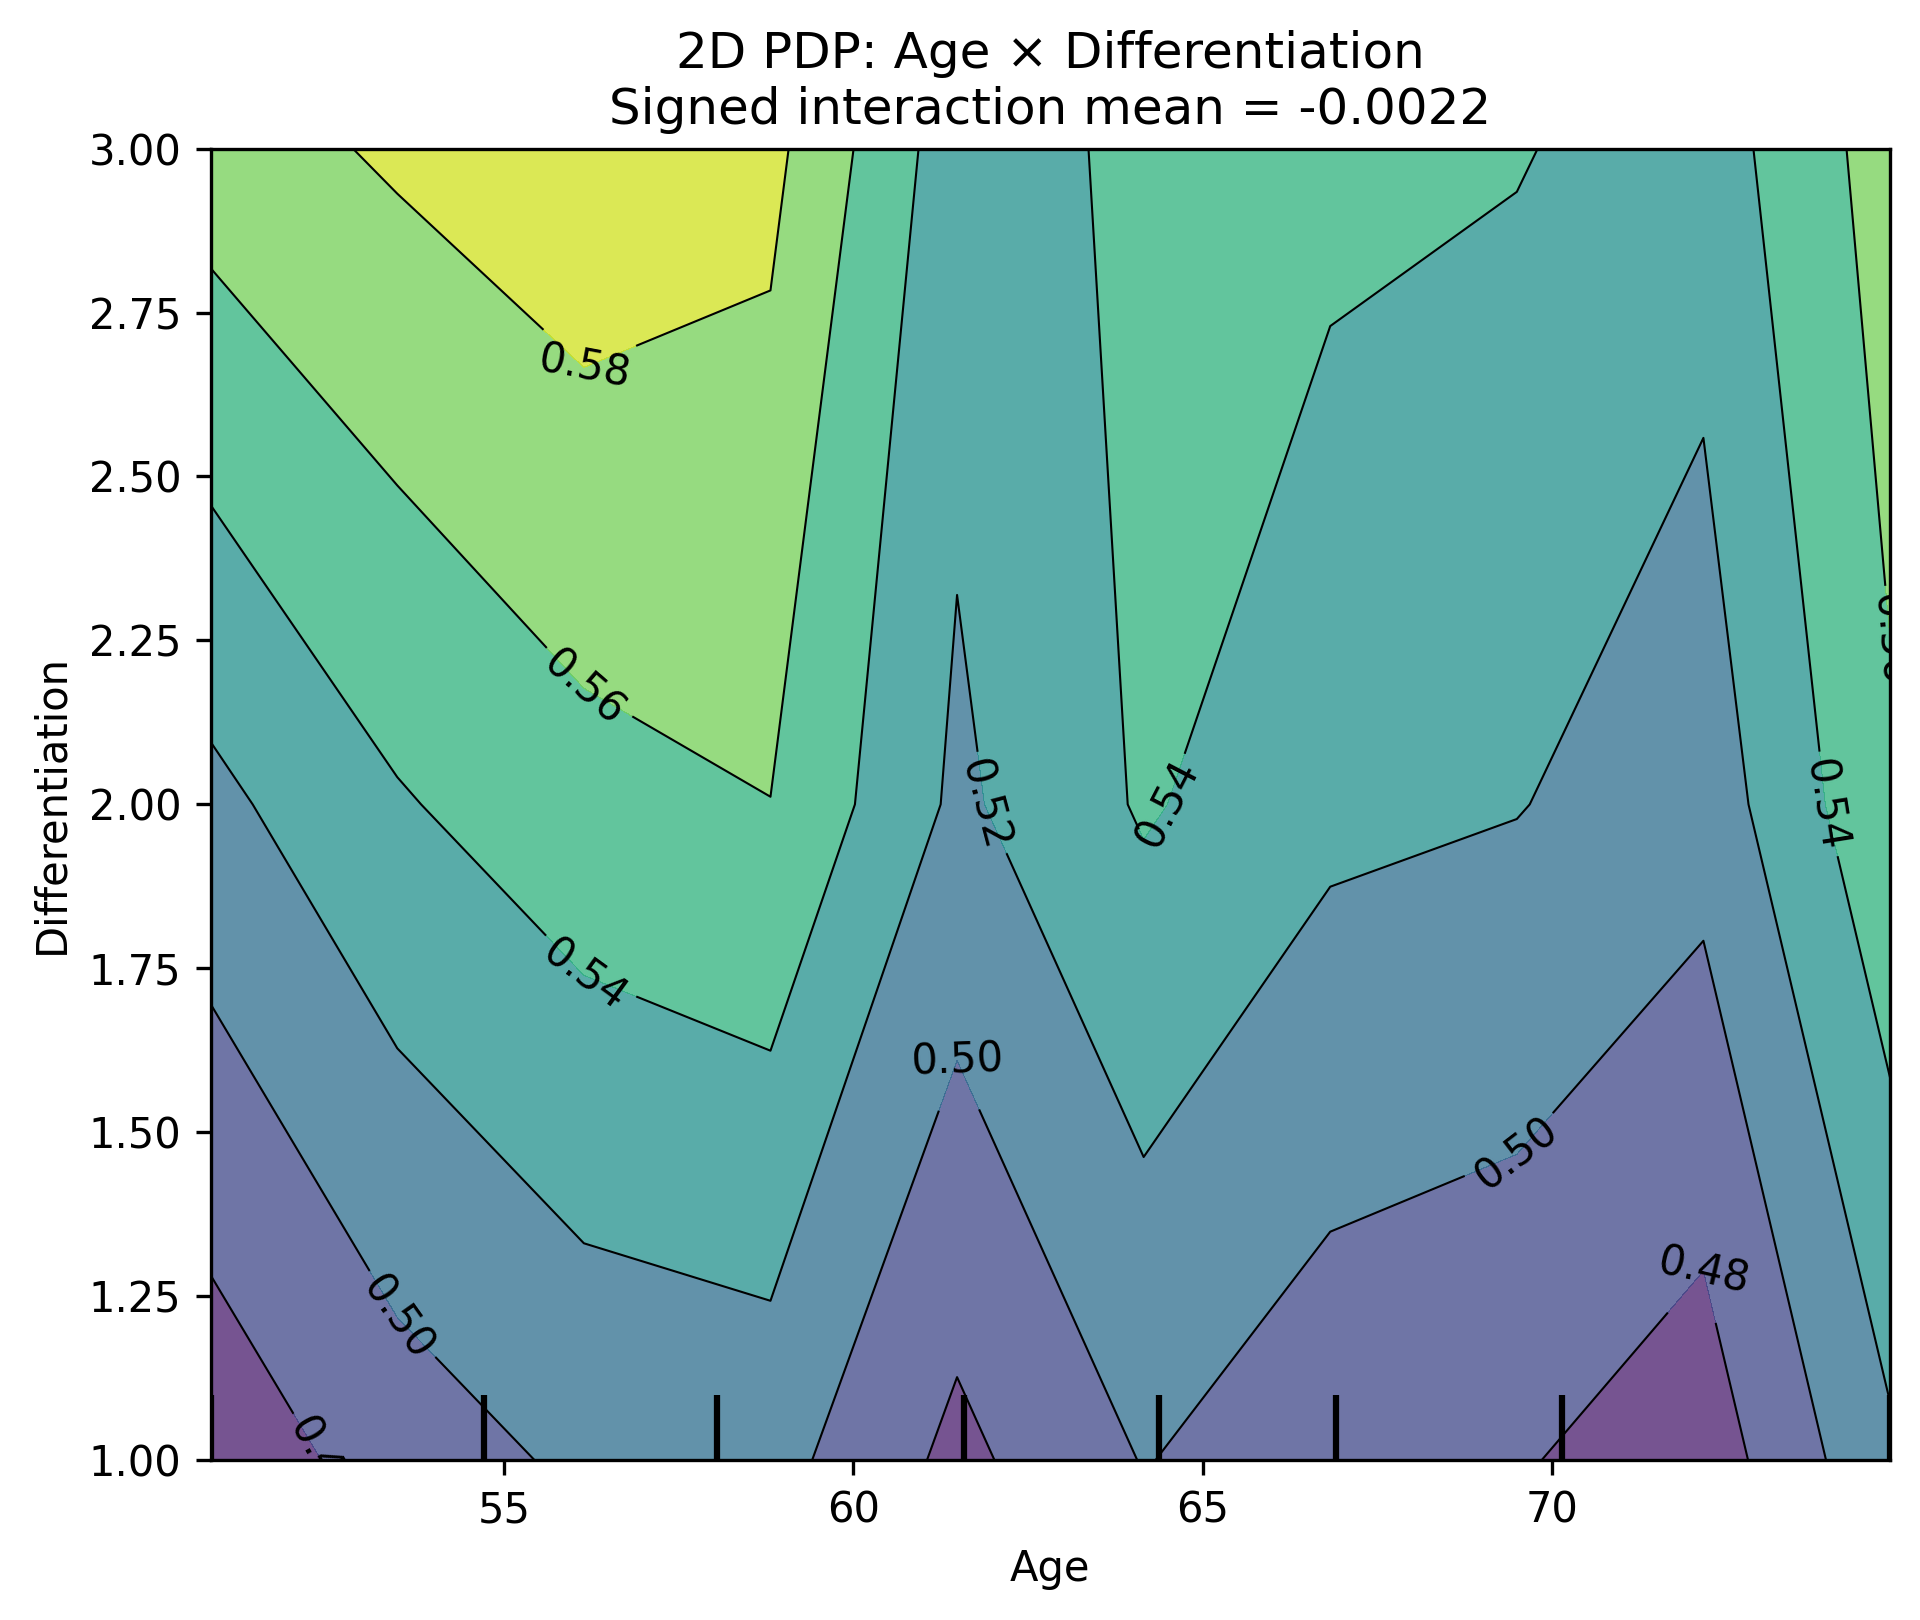

In [55]:
class SklearnClassifierWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y=None):
        self.classes_ = np.array([0, 1])
        self.n_features_in_ = X.shape[1]

        if hasattr(X, "columns"):
            self.feature_names_in_ = np.array(X.columns)

        return self

    def predict_proba(self, X):
        proba = np.asarray(self.model.predict_proba(X))

        if proba.ndim == 1:
            proba = np.column_stack([1 - proba, proba])

        return proba

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


pdp_model = SklearnClassifierWrapper(best_model)
pdp_model.fit(X_train, y_train)

for _, row in selected_pair_df.iterrows():
    f1 = row["feature_1"]
    f2 = row["feature_2"]

    fig, ax = plt.subplots(figsize=(6.5, 5.5), dpi=300)

    PartialDependenceDisplay.from_estimator(
        estimator=pdp_model,
        X=X_train,
        features=[(f1, f2)],
        response_method="predict_proba",
        method="brute",
        kind="average",
        grid_resolution=10,
        percentiles=(0.20, 0.90),
        ax=ax
    )

    ax.set_title(
        f"2D PDP: {f1} × {f2}\n"
        f"Signed interaction mean = {row['interaction_signed_mean']:.4f}"
    )

    plt.tight_layout()

    out_name = (
        f"{PDP_DIR}/{safe_name}_pdp_2d_"
        f"{safe_text(f1)}__{safe_text(f2)}.pdf"
    )

    plt.savefig(out_name, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()



In [56]:
pdp_index_df = selected_pair_df.copy()

pdp_index_df["output_file"] = pdp_index_df.apply(
    lambda r: f"{safe_name}_pdp_2d_{safe_text(r['feature_1'])}__{safe_text(r['feature_2'])}.pdf",
    axis=1
)

pdp_index_df.to_csv(
    f"{PDP_DIR}/{safe_name}_pdp_2d_output_index.csv",
    index=False,
    encoding="utf-8-sig"
)